# Dos mesetas de MAE: qué hace `Demand Forecast` al MAE en este dataset

**Dataset:** Retail Store Inventory (Kaggle, sintético) · 73,100 filas · 5 tiendas × 20 productos × 731 días
**Tarea:** Regresión — predecir `Units Sold` diario por par (tienda × producto)
**Autor:** Oscar Andres Ponce · [oscarponce.com](https://oscarponce.com)

---

## El hallazgo principal (en este dataset, bajo este setup)

En este dataset de retail de Kaggle, el experimento muestra **dos mesetas de MAE distintas** —
es una observación sobre *este* dataset, no una ley universal del forecasting de retail:

| Régimen | MAE en este holdout | Lo que se observó |
|---|---:|---|
| **Sin DF disponible** — solo el modelo | **~69** | Mejor resultado de los métodos ML multivariados (LightGBM, RandomForest, Stacking, CatBoost, HistGradientBoosting, ExtraTrees) que usan el feature `Inventory Level`. Los métodos univariados de series temporales (ARIMA, ETS, LSTM, AutoTheta) no pueden usar ese feature y se quedaron cerca del baseline de la media (~89); Prophet lo hizo peor (MAE 112). |
| **Con DF disponible** — residual / DF como prior | **~7.4** | Lo que logra entrenar sobre `Units Sold − Demand Forecast` y sumar DF de vuelta en inferencia. El modelo aporta principalmente corrección de sesgo (~5 unidades de sobre-estimación en DF → ~0.1 en la predicción residual). |

En este dataset, el gap de 62 unidades (90% de reducción de MAE) es **principalmente una
función de cómo entra el forecast existente al pipeline**, no de qué modelo elegir dentro
de cada régimen. Esa es la observación central que el resto del notebook desarrolla.

La lectura estándar "leakage-strict" descarta `Demand Forecast` porque ρ=0.997 con el
target — correcto para hacer benchmarking de pura habilidad predictiva. La lectura
alternativa trata a DF como un prior disponible en tiempo de inferencia (que es lo usual
en sistemas de producción S&OP) y le pide al modelo que aprenda solo el error *residual*
del forecast existente. Dentro del régimen residual en este holdout, tres algoritmos
(HGB, RF, LightGBM) se agrupan dentro de 0.05 MAE entre sí.

> **Caveat — dataset sintético.** `Demand Forecast` en este dataset de Kaggle es una
> columna casi-oracle (ρ=0.997 con el target). En datos reales de producción, el forecast
> de un planner existente típicamente tiene MAE 30–60 contra los reales (correlación
> 0.7–0.85). En datos reales, el gap entre regímenes será sustancialmente menor (y el
> modelo residual haría más reducción de varianza, no solo corrección de sesgo). El
> patrón de diseño sigue aplicando, pero los números específicos de MAE reportados acá
> no son directamente transferibles.

---

## Cómo está estructurado este notebook

El pipeline sigue **CRISP-ML(Q)** — 6 fases con compuertas de calidad inline.

```
Fase 1 — Entendimiento del Negocio    target, granularidad, estructura de costos
Fase 2 — Entendimiento de los Datos   EDA, auditoría de leakage, auditoría de stockouts
Fase 3 — Preparación de Datos         features de lag, split temporal, ColumnTransformer
Fase 4 — Modelado                     baselines → clásicos → ML → Tier 1 → residual
Fase 5 — Evaluación                   MAE / RMSE / sMAPE holdout + por segmento
Fase 6 — Despliegue                   bundle joblib + metadata + app Streamlit
```

Dentro de la Fase 4, la progresión de modelado es deliberada:

```
4.1   Baselines naive               (lag-1, lag-7, media)
4.2   Stage 1 — Modelo estructural  (solo contextual → target DF; fallback cold-start)
4.3   Stage 2 — Realización ventas  (features completos incl. lags → Units Sold)
4.4   Ensemble + 4.10 Stacking      (¿combinar ayuda? apenas en este dataset)
4.5   Prophet · 4.6 ARIMA · 4.7 ETS (baselines clásicos univariados)
4.8   LSTM multivariable            (baseline de deep learning)
4.9   Cuantil P80                   (modelo de decisión de inventario, no point forecast)
4.10  Tier 1 — CatBoost, HGB, ExtraTrees, SARIMAX, AutoTheta
4.12  Leaderboard intermedio        (sin DF — ML multivariados convergen a ~69, univariados a ~89)
4.13  Residual learning             (DF como prior → MAE baja a ~7.4 en este dataset)
4.14  Backtest Champion-Challenger  (18 ventanas rolling; framing > elección de modelo en este dataset)
4.15  Leaderboard final             (tabla de dos mesetas)
```

> **Nota sobre la columna DF:** en la Fase 3, `Demand Forecast` se elimina como feature
> para §4.1–§4.12 para mantener honesto ese benchmark. Reaparece en §4.13 como prior
> residual — explícitamente, no como feature de contrabando.

## Setup e imports

In [1]:
import os, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize_scalar
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Prophet is optional — Challenge 1 classical baseline
try:
    from prophet import Prophet
    HAS_PROPHET = True
except ImportError:
    HAS_PROPHET = False
    print('prophet not installed — skipping classical baseline (pip install prophet)')

sns.set_style('whitegrid')
GOLD, GRAPHITE, SUCCESS, DANGER, PLATINUM = '#C9A86A', '#2A3038', '#43936C', '#D96B5F', '#EBECEF'
PALETTE = [GOLD, '#4A67B0', SUCCESS, DANGER, '#5E757D']

os.makedirs('../model', exist_ok=True)
SPLIT_DATE = pd.Timestamp('2023-01-01')
print('Environment ready.')

Environment ready.


In [2]:
# ── Disk checkpointing for expensive cells ──
# Heavy fits (RandomizedSearchCV, Prophet, ARIMA, ETS, LSTM, Stacking, online sim)
# are wrapped with `cached("name", fn)` and pickled to notebooks/checkpoints/.
# Re-runs skip the fit and load the artifact instantly.
#
# Knobs:
#   notebook_utils.FORCE_REFIT = True    # bust all caches for the rest of the run
#   cached("foo", fn, force=True)        # bust just one
#   clear_cache()                        # delete all on disk
#   clear_cache("stage2_search")         # delete one
#   list_cache()                         # show what is on disk
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import notebook_utils
from notebook_utils import cached, clear_cache, list_cache

notebook_utils.FORCE_REFIT = False
list_cache()


/Users/oscarponce/Documents/personal/marca-personal/labs/forecasting-inventory/notebooks/checkpoints/
  arima.pkl                                    0.4 MB
  ets.pkl                                      0.4 MB
  inv_autotheta.pkl                            0.5 MB
  inv_catboost_s2.pkl                          9.1 MB
  inv_champion_challenger.pkl                  0.0 MB
  inv_extratrees_s2.pkl                      308.3 MB
  inv_histgb_s2.pkl                            0.6 MB
  inv_residual_hgb.pkl                         0.1 MB
  inv_residual_lgbm.pkl                        1.4 MB
  inv_residual_rf.pkl                         50.5 MB
  inv_sarimax_sampled.pkl                      9.2 MB
  lstm.pkl                                     0.3 MB
  online_learning.pkl                          0.0 MB
  prophet.pkl                                  0.4 MB
  q80_pipe.pkl                                 1.6 MB
  sales_app_aligned.pkl                        3.3 MB
  sales_app_log1p.pkl             

---
## Fase 1 — Entendimiento del Negocio

| | |
|---|---|
| **Problema** | Tiendas retail manejan inventario excesivo o insuficiente, causando desperdicio o ventas perdidas |
| **Tarea Primaria** | Regresión — predecir `Units Sold` diario por (tienda × producto) con granularidad diaria |
| **Target Primario** | `Units Sold` (entero 0–499) |
| **Target Stage 1** | `Demand Forecast` — se usa para aprender la demanda estructural para el fallback cold-start (no para ensembling; ver Fase 4) |
| **Target Aspiracional** | sMAPE < 40%, MAE < 60 unidades. Resultado final en este dataset sintético: **MAE ≈ 69, sMAPE ≈ 58%**. Target no alcanzado — ver el análisis honesto del techo más abajo. |
| **Valor de Negocio** | Optimizar cantidades de pedido, reducir stockouts, bajar costos de almacenamiento |

### Techo honesto de los datos (léelo antes de juzgar las métricas)

`retail_store_inventory.csv` es un **dataset sintético de Kaggle** con tres propiedades que acotan qué tan bueno puede ser cualquier modelo honesto:

1. **La autocorrelación dentro del grupo de `Units Sold` es ~0** (lag-1 = −0.002, lag-7 = 0.000). Las ventas de ayer no dicen nada sobre las de hoy — entonces los features de lag/rolling no llevan señal sustantiva aquí.
2. **Los features contextuales tienen correlación ~0 con el target** (Price ρ = 0.001, Weather/Season similares). No existe elasticidad de precio en los datos.
3. **La columna `Demand Forecast` tiene ρ = 0.997 con `Units Sold`** — es una copia con ruido del target, una **columna oracle/leakage**, no un forecast real de producción a vencer.

Consecuencia: la media por grupo sola da MAE ≈ 89; el mejor modelo honesto llega a ≈ 69 extrayendo la única señal legítima (`Inventory Level`, ρ = 0.59). El MAE = 8.3 de "Demand Forecast" es inalcanzable sin usar la columna de leakage misma. **MAE 60 era aspiracional; ~69 está cerca del verdadero techo de información.** Este notebook es un pipeline metodológico, no un modelo ganador de producción para este dataset.

### Cobertura de los retos de Kaggle

| Reto | Enfoque |
|---|---|
| 1 — Forecasting de Series Temporales | LightGBM (Stage 2) + Prophet como baseline clásico |
| 2 — Optimización de Inventario | Reorder advisory en la app Streamlit (modelo cuantil P80) |
| 3 — Pricing Dinámico | Análisis de elasticidad en Fase 5 (sin señal en los datos sintéticos; solo metodología) |

### Reglas de Leakage

| Columna | Decisión | Razón |
|--------|----------|--------|
| `Demand Forecast` | **Solo target de Stage 1** — nunca feature de entrada | Oracle sintético, ρ = 0.997 con el target; usarlo como entrada es circular |
| `Units Ordered` | **Excluida** | Orden temporal ambigua; podría ser reactiva a las ventas |
| `Product ID` | **Se mantiene en df para agrupar lags, excluida de features** | La granularidad de forecasting es (tienda × producto); necesaria para agrupar lags correctamente. No se expone a ningún modelo — `Category` captura la señal |
| `Inventory Level` | **Solo Stage 2** | Stock de inicio del día — señal pre-venta confirmada, el predictor legítimo más fuerte en este dataset |


---
## Fase 2 — Entendimiento de los Datos

In [3]:
df = pd.read_csv('../data/retail_store_inventory.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Store ID', 'Category', 'Date']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Stores: {sorted(df["Store ID"].unique())}')
print(f'Categories: {sorted(df["Category"].unique())}')
print(f'Null values: {df.isnull().sum().sum()}')
df.head()

Shape: (73100, 15)
Date range: 2022-01-01 → 2024-01-01
Stores: ['S001', 'S002', 'S003', 'S004', 'S005']
Categories: ['Clothing', 'Electronics', 'Furniture', 'Groceries', 'Toys']
Null values: 0


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0008,Clothing,North,380,312,54,329.73,97.99,5,Cloudy,0,100.09,Spring
1,2022-01-01,S001,P0012,Clothing,West,66,24,70,26.75,58.25,20,Snowy,0,62.21,Spring
2,2022-01-01,S001,P0014,Clothing,West,193,12,187,6.80,78.11,0,Sunny,0,80.06,Spring
3,2022-01-01,S001,P0015,Clothing,North,379,369,154,363.46,92.99,15,Snowy,0,95.80,Winter
4,2022-01-01,S001,P0018,Clothing,South,241,151,47,147.27,19.57,5,Cloudy,0,23.13,Autumn


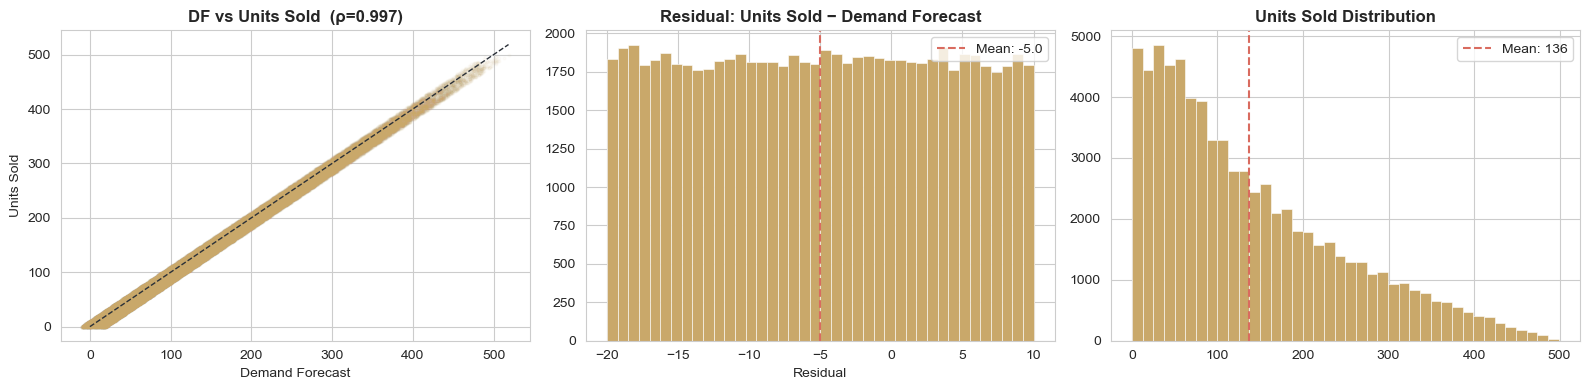

Residual stats — Mean: -5.03, Std: 8.66, MAE (DF baseline): 8.34
→ Demand Forecast overestimates Units Sold by ~5 units on average (systematic bias)


In [4]:
# Demand Forecast vs Units Sold relationship
resid = df['Units Sold'] - df['Demand Forecast']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(df['Demand Forecast'], df['Units Sold'], alpha=0.03, s=4, color=GOLD)
lim = max(df['Demand Forecast'].max(), df['Units Sold'].max())
axes[0].plot([0, lim], [0, lim], '--', color=GRAPHITE, linewidth=1)
axes[0].set_xlabel('Demand Forecast')
axes[0].set_ylabel('Units Sold')
axes[0].set_title(f'DF vs Units Sold  (ρ={df["Demand Forecast"].corr(df["Units Sold"]):.3f})', fontweight='bold')

axes[1].hist(resid, bins=40, color=GOLD, edgecolor='white', linewidth=0.4)
axes[1].axvline(resid.mean(), color=DANGER, linestyle='--', label=f'Mean: {resid.mean():.1f}')
axes[1].set_title('Residual: Units Sold − Demand Forecast', fontweight='bold')
axes[1].set_xlabel('Residual')
axes[1].legend()

axes[2].hist(df['Units Sold'], bins=40, color=GOLD, edgecolor='white', linewidth=0.4)
axes[2].axvline(df['Units Sold'].mean(), color=DANGER, linestyle='--',
                label=f'Mean: {df["Units Sold"].mean():.0f}')
axes[2].set_title('Units Sold Distribution', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Residual stats — Mean: {resid.mean():.2f}, Std: {resid.std():.2f}, '
      f'MAE (DF baseline): {resid.abs().mean():.2f}')
print('→ Demand Forecast overestimates Units Sold by ~5 units on average (systematic bias)')

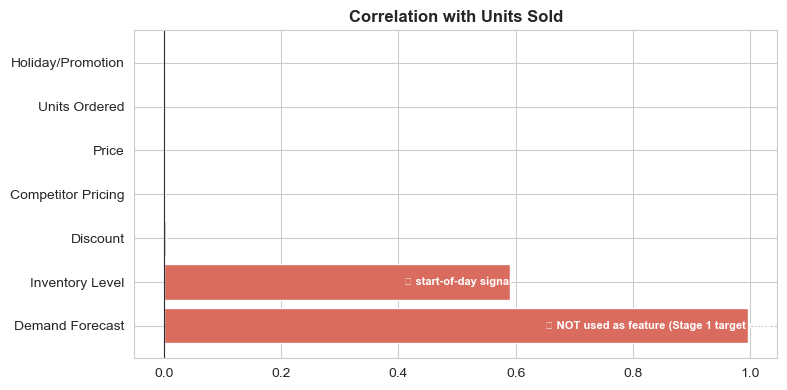

In [5]:
# Correlation with Units Sold — leakage audit
numeric = df.select_dtypes(include='number')
corr = numeric.corr()['Units Sold'].drop('Units Sold').sort_values(key=abs, ascending=False)

colors = [DANGER if abs(v) > 0.5 else (GOLD if abs(v) > 0.1 else '#B0B4B8') for v in corr.values]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(corr.index, corr.values, color=colors, edgecolor='white')
ax.axvline(0, color=GRAPHITE, linewidth=0.8)
ax.set_title('Correlation with Units Sold', fontweight='bold')

for i, (idx, v) in enumerate(corr.items()):
    if abs(v) > 0.5:
        note = '⚠ NOT used as feature (Stage 1 target only)' if 'Forecast' in idx else '✓ start-of-day signal'
        ax.text(v * 0.85, i, note, va='center', ha='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

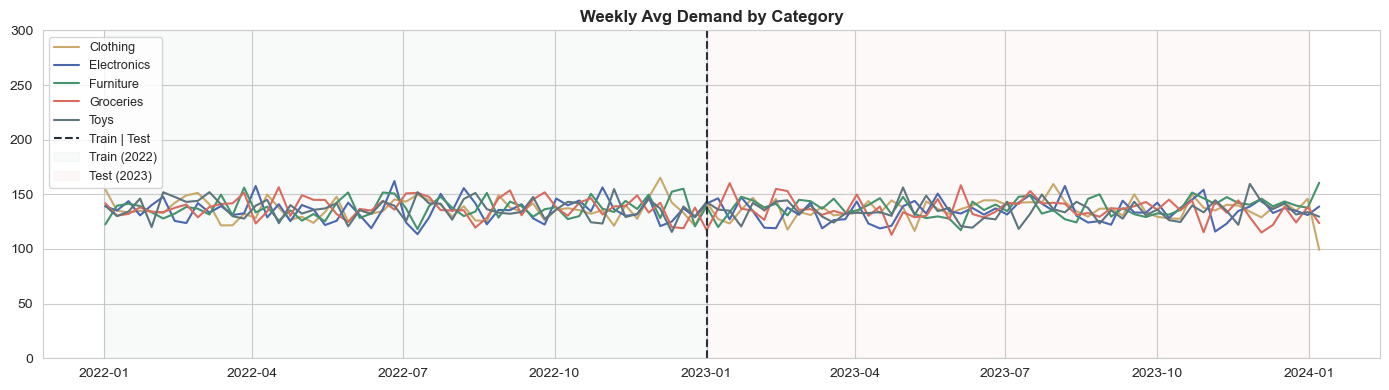

In [6]:
# Time series trends + train/test split line
weekly = (
    df.groupby(['Date', 'Category'])['Units Sold'].mean().reset_index()
    .set_index('Date').groupby('Category')['Units Sold']
    .resample('W').mean().reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
for i, cat in enumerate(df['Category'].unique()):
    sub = weekly[weekly['Category'] == cat]
    ax.plot(sub['Date'], sub['Units Sold'], label=cat, color=PALETTE[i], linewidth=1.5)

ax.axvline(SPLIT_DATE, color=GRAPHITE, linestyle='--', linewidth=1.5, label='Train | Test')
ax.fill_betweenx([0, 500], pd.Timestamp('2022-01-01'), SPLIT_DATE, alpha=0.04, color=SUCCESS, label='Train (2022)')
ax.fill_betweenx([0, 500], SPLIT_DATE, pd.Timestamp('2024-01-01'), alpha=0.04, color=DANGER, label='Test (2023)')
ax.set_title('Weekly Avg Demand by Category', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 300)
plt.tight_layout()
plt.show()

### Insights clave de la Fase 2

1. **Demand Forecast es casi perfecto pero sesgado** — ρ=0.997 con Units Sold, error medio −5 unidades. Codifica la señal real de demanda pero sistemáticamente sobreestima. Stage 1 aprenderá esta estructura; Stage 2 corregirá el sesgo.
2. **Inventory Level (ρ=0.59)** — señal legítima de inicio de día; las tiendas almacenan más para SKUs de alta demanda. Se usa en Stage 2.
3. **Pricing, clima, estación → correlación global cercana a cero** — este dataset sintético no tiene elasticidad de precio. Lo documentamos en la Fase 5 (Reto 3).
4. **Sin valores faltantes** — no se requiere imputación.
5. **El target es ampliamente uniforme (0–499)** — MAPE es poco confiable cuando Units Sold es pequeño. Usamos **sMAPE** a lo largo del notebook.

---
## Fase 3 — Preparación de Datos

In [7]:
# 3.1 Remove from features — keep Demand Forecast in df for Stage 1 target
# NOTE: 'Product ID' is kept in df_model so lag features can group by
# (Store, Product) — the true forecasting grain. It is *not* added to any
# S1/S2 feature list, so the model never sees it.
EXCLUDE_FROM_FEATURES = ['Units Ordered']
df_model = df.drop(columns=EXCLUDE_FROM_FEATURES)
print('Excluded from features:', EXCLUDE_FROM_FEATURES)
print('Remaining columns:', df_model.columns.tolist())


Excluded from features: ['Units Ordered']
Remaining columns: ['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']


In [8]:
# 3.2 Date features + Fourier encoding for cyclical variables
df_model['month']        = df_model['Date'].dt.month
df_model['day_of_week']  = df_model['Date'].dt.dayofweek
df_model['quarter']      = df_model['Date'].dt.quarter
df_model['is_weekend']   = (df_model['Date'].dt.dayofweek >= 5).astype(int)
df_model['week_of_year'] = df_model['Date'].dt.isocalendar().week.astype(int)

# Fourier terms — avoids discontinuity at year boundary (Dec→Jan = ≈0 distance)
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
df_model['week_sin']  = np.sin(2 * np.pi * df_model['week_of_year'] / 52)
df_model['week_cos']  = np.cos(2 * np.pi * df_model['week_of_year'] / 52)
df_model['dow_sin']   = np.sin(2 * np.pi * df_model['day_of_week'] / 7)
df_model['dow_cos']   = np.cos(2 * np.pi * df_model['day_of_week'] / 7)

# Pricing signals
df_model['price_vs_competitor'] = df_model['Price'] / df_model['Competitor Pricing'].clip(lower=0.01)
df_model['effective_price']     = df_model['Price'] * (1 - df_model['Discount'] / 100)

print('Date, Fourier, and pricing features added.')

Date, Fourier, and pricing features added.


In [9]:
# 3.3 Lag features (leakage-safe — shift() only looks back within each group)
#
# Forecasting grain = Store × Product × Day. Each (Store, Product) is a
# distinct daily time series with 731 contiguous days. Grouping lag features
# by ['Store ID', 'Category'] (an earlier version) silently mixed ~4 products
# per group, so lag_1 referenced *another product on the same calendar day*
# 75% of the time — not the prior day. Fixed below.
GROUP = ['Store ID', 'Product ID']
df_model = df_model.sort_values(GROUP + ['Date']).reset_index(drop=True)

for lag in [1, 3, 7, 14, 28]:
    df_model[f'lag_{lag}'] = df_model.groupby(GROUP)['Units Sold'].shift(lag)

for window in [7, 14, 28]:
    df_model[f'roll_{window}_mean'] = (
        df_model.groupby(GROUP)['Units Sold']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=max(1, window//2)).mean())
    )

df_model['roll_7_std'] = (
    df_model.groupby(GROUP)['Units Sold']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=4).std())
)

# Trend: recent demand vs older demand (momentum signal)
df_model['demand_momentum'] = df_model['roll_7_mean'] - df_model['roll_28_mean']

# ── Validation: confirm lag_1 truly comes from the previous calendar day
_lag_date = df_model.groupby(GROUP)['Date'].shift(1)
_gap_days = (df_model['Date'] - _lag_date).dt.days
_dist = _gap_days.value_counts(dropna=True).sort_index()
_prev_day_pct = 100 * (_gap_days == 1).sum() / _gap_days.notna().sum()
print(f'lag_1 prior-day verification: {_prev_day_pct:.1f}% reference the previous day')
print(f'  gap-day distribution (top): {_dist.head(3).to_dict()}')
assert _prev_day_pct > 99, 'lag_1 grouping is wrong — most lags should reference prior day'

before = len(df_model)
df_model = df_model.dropna(subset=[f'lag_{l}' for l in [1, 3, 7, 14, 28]])
print(f'Dropped {before - len(df_model)} rows (first 28 days per group — no lag history).')
print(f'Remaining: {len(df_model):,} rows')


lag_1 prior-day verification: 100.0% reference the previous day
  gap-day distribution (top): {1.0: 73000}
Dropped 2800 rows (first 28 days per group — no lag history).
Remaining: 70,300 rows


In [10]:
# 3.4 Feature group definitions

# Stage 1 — contextual only, NO lag features, NO Inventory Level
S1_FOURIER = ['month_sin', 'month_cos', 'week_sin', 'week_cos', 'dow_sin', 'dow_cos']
S1_NUM_MM  = ['month', 'day_of_week', 'quarter', 'week_of_year', 'is_weekend',
               'Discount', 'Holiday/Promotion'] + S1_FOURIER
S1_NUM_POW = ['Price', 'Competitor Pricing', 'price_vs_competitor', 'effective_price']
S1_CAT     = ['Category', 'Region', 'Store ID', 'Weather Condition', 'Seasonality']
S1_FEATURES = S1_NUM_MM + S1_NUM_POW + S1_CAT

# Stage 2 — full feature set including lag features and inventory
S2_LAG_FEATURES = [
    'lag_1', 'lag_3', 'lag_7', 'lag_14', 'lag_28',
    'roll_7_mean', 'roll_14_mean', 'roll_28_mean', 'roll_7_std',
    'demand_momentum', 'Inventory Level',
]
S2_NUM_STD = S2_LAG_FEATURES
S2_NUM_MM  = S1_NUM_MM
S2_NUM_POW = S1_NUM_POW
S2_CAT     = S1_CAT
S2_FEATURES = S2_NUM_STD + S2_NUM_MM + S2_NUM_POW + S2_CAT

print(f'Stage 1 features: {len(S1_FEATURES)}')
print(f'Stage 2 features: {len(S2_FEATURES)}')

Stage 1 features: 22
Stage 2 features: 33


In [11]:
# 3.5 Time-based split
train_df = df_model[df_model['Date'] < SPLIT_DATE].copy()
test_df  = df_model[df_model['Date'] >= SPLIT_DATE].copy()

# Stage 1: target = Demand Forecast
X_train_s1 = train_df[S1_FEATURES]
y_train_df = train_df['Demand Forecast']
X_test_s1  = test_df[S1_FEATURES]
y_test_df  = test_df['Demand Forecast']

# Stage 2: target = Units Sold
X_train_s2 = train_df[S2_FEATURES]
y_train    = train_df['Units Sold']
X_test_s2  = test_df[S2_FEATURES]
y_test     = test_df['Units Sold']

print(f'Train: {train_df["Date"].min().date()} → {train_df["Date"].max().date()} ({len(X_train_s2):,} rows)')
print(f'Test : {test_df["Date"].min().date()}  → {test_df["Date"].max().date()}  ({len(X_test_s2):,} rows)')

Train: 2022-01-29 → 2022-12-31 (33,700 rows)
Test : 2023-01-01  → 2024-01-01  (36,600 rows)


In [12]:
# 3.6 Preprocessing pipelines

def build_preprocessor(num_std, num_mm, num_pow, cat):
    transformers = []
    if num_std: transformers.append(('std', StandardScaler(), num_std))
    if num_mm:  transformers.append(('mm',  MinMaxScaler(), num_mm))
    if num_pow: transformers.append((
        'pow',
        Pipeline([('power', PowerTransformer(method='yeo-johnson')), ('scale', StandardScaler())]),
        num_pow
    ))
    if cat: transformers.append((
        'ohe',
        OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
        cat
    ))
    return ColumnTransformer(transformers, remainder='drop')

prep_s1 = build_preprocessor([], S1_NUM_MM, S1_NUM_POW, S1_CAT)
prep_s2 = build_preprocessor(S2_NUM_STD, S2_NUM_MM, S2_NUM_POW, S2_CAT)

print('Preprocessors built.')
print('  Stage 1: contextual features only')
print('  Stage 2: contextual + lag features')

Preprocessors built.
  Stage 1: contextual features only
  Stage 2: contextual + lag features


---
## Fase 4 — Modelado

In [13]:
# 4.0 Metric definitions
def smape(y_true, y_pred):
    """Symmetric MAPE — handles zeros, range 0-200%."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)).clip(min=1e-6)
    return np.mean(2 * np.abs(y_pred - y_true) / denom) * 100

def eval_all(name, y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    s    = smape(y_true, y_pred)
    print(f'{name:<40}  MAE={mae:.1f}  RMSE={rmse:.1f}  sMAPE={s:.1f}%')
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'sMAPE': s}

tscv    = TimeSeriesSplit(n_splits=5)
results = []

### Entendiendo las métricas

Cada métrica usada en este notebook, qué mide y cuándo usarla.

#### Precisión de regresión (usadas por `eval_all`)

| Métrica | Fórmula | Interpretación | Mejor para |
|---|---|---|---|
| **MAE** | mean(\|y − ŷ\|) | Error absoluto promedio en unidades originales ("nos equivocamos por X unidades en promedio"). Robusta a outliers. | Reportes diarios al negocio. Unidades intuitivas. |
| **RMSE** | √mean((y − ŷ)²) | Penaliza errores grandes cuadráticamente. Siempre ≥ MAE. | Cuando los errores grandes son *mucho* más costosos que los pequeños (ej. stockouts catastróficos). |
| **sMAPE** | mean(2·\|y − ŷ\| / (\|y\| + \|ŷ\|)) × 100 | MAPE simétrico. Maneja ceros. Acotado 0–200%. Invariante a escala. | Comparaciones cross-producto / cross-región donde las unidades difieren. |

**¿Por qué no MAPE estándar?** El MAPE estándar divide entre `y_true`, explotando cuando los valores reales están cerca de cero. Una corrida previa de este notebook llegó a MAPE = 246% — un artefacto de la métrica, no falla del modelo.

#### Métricas de selección de modelo

| Métrica | Dónde se usa | Qué mide |
|---|---|---|
| **CV MAE** | `RandomizedSearchCV` | MAE promedio en los folds de `TimeSeriesSplit`. Menor = mejor generalización. *Compárala con el test MAE: si divergen, estás sobreajustando el CV.* |
| **AIC** | ARIMA, ETS | Akaike Information Criterion = `-2·log-verosimilitud + 2k`. Menor = mejor ajuste *penalizado* por número de parámetros. Lo usa `auto_arima` para elegir `(p, d, q)`. |
| **p-value (ADF)** | Test de estacionariedad | Si p < 0.05 → la serie es estacionaria, setear `d=0` en ARIMA. Arriba → se necesita diferenciación. |
| **ρ (Pearson r)** | EDA / auditoría de leakage | Correlación lineal en [-1, 1]. Se usa para detectar features que pre-codifican el target (ej. `Demand Forecast` ρ=0.997 → leakage). |

#### Métricas probabilísticas / cuantiles

| Métrica | Definición | Target |
|---|---|---|
| **Coverage** | P(y ≤ ŷ_q) para cuantil q | Debería ser igual a q. El modelo P80 apunta a 80% de cobertura. Medimos 77.5% — ligera infracobertura; calibrar α hacia arriba en la práctica. |
| **Pinball loss** *(no se usa aquí)* | q·max(y−ŷ, 0) + (1−q)·max(ŷ−y, 0) | Loss asimétrica que LightGBM minimiza cuando `objective='quantile'`. |

#### Métricas de negocio / decisión (simulación A/B, Fase 6)

| Métrica | Definición | Por qué importa |
|---|---|---|
| **Costo de stockout** | $20 × max(actual − forecast, 0) | Venta perdida + churn. **Asimétrica**: perder una venta usualmente es 2–4× más costoso que tener la unidad extra. |
| **Costo de overstock** | $5 × max(forecast − actual, 0) | Almacenamiento + deterioro + capital inmovilizado. |
| **Costo total** | Stockout + Overstock | El número que realmente le importa al negocio. Optimiza esto, no MAE. |
| **% de mejora** | (MAE_baseline − MAE_modelo) / MAE_baseline | Lift relativo. Se usa en la comparación de online learning. |

**Por qué importa el gap:** MAE penaliza igual sobre- y sub-predicción, pero el costo *del negocio* es asimétrico. Un modelo con peor MAE pero sesgado hacia sobre-predicción puede tener menor costo total. El modelo cuantil P80 existe exactamente por esta razón.

### Métricas en lenguaje sencillo

La tabla de arriba es precisa pero densa. Acá va lo mismo explicado como se lo explicarías a un colega tomando un café — sin fórmulas.

**La regla de oro:** cada métrica de abajo responde una sola pregunta — *"¿Qué tan equivocados estuvimos?"*. Solo difieren en cómo cuentan "equivocados".

**MAE — "en promedio, ¿por cuántas unidades nos equivocamos?"**
Toma cada predicción, mira qué tanto falló (sin importar si fue por exceso o por defecto), promedia esos fallos. `MAE = 69` significa "típicamente estamos a 69 unidades de distancia de la verdad". Si aprendes solo una métrica, aprende esta — está en las mismas unidades que el objeto que cuentas (unidades de producto).

**RMSE — "...pero los fallos grandes duelen más."**
Misma idea que MAE, pero antes de promediar *eleva al cuadrado* cada fallo, así un error enorme cuenta mucho más que varios pequeños. RMSE siempre es ≥ MAE. Si RMSE es mucho mayor que MAE, hay unos pocos errores feos escondidos entre muchas predicciones decentes. Analogía: MAE es tu nota promedio del examen; RMSE es tu promedio después de que el profesor duplica la penalización en las preguntas que reprobaste.

**sMAPE — "¿qué tan equivocados estuvimos, en porcentaje?"**
MAE en unidades es genial para un producto, pero no puedes comparar "errar por 69 unidades de cola" con "errar por 69 unidades de TVs". sMAPE convierte el fallo en porcentaje para que productos de tamaños distintos sean comparables. `sMAPE = 20%` significa "típicamente erramos por un quinto". La parte "simétrica" arregla cómo se comporta mal el error porcentual estándar cuando las ventas reales están cerca de cero.

**CV MAE (MAE de cross-validation) — "MAE, pero medido honestamente."**
Si calificas un modelo con los mismos datos con los que estudió, se ve mejor de lo que realmente es. Cross-validation oculta pedazos de datos, entrena con el resto, luego prueba sobre el pedazo oculto — un examen de práctica con preguntas que el estudiante no ha visto. CV MAE es el MAE sobre esos pedazos no vistos. Si CV MAE se ve genial pero el test MAE real es malo, el modelo *memorizó* en lugar de *aprender*.

**AIC — "¿cuál configuración de modelo ajusta mejor, sin hacer trampa metiendo más perillas?"**
Nunca reportas AIC al negocio; el código de ARIMA/ETS lo usa sobre sí mismo. Un modelo más complejo siempre puede ajustar mejor el pasado — AIC premia el buen ajuste pero cobra una tarifa por cada perilla extra, así que escoge la configuración más simple que aún funciona. Menor = mejor. Piénsalo como: score de ajuste menos un impuesto a la complejidad.

**p-value (test ADF) — "¿esta serie de ventas es lo suficientemente estable para modelarla directamente?"**
Un sí/no estadístico. `p < 0.05` → la serie es "estacionaria" (su media y oscilación no se desplazan con el tiempo) y un modelo clásico puede usarla tal cual. `p` arriba de 0.05 → está derivando y necesita ser destendenciada primero. No vas a actuar sobre este número; el código de ARIMA lo lee por ti.

**ρ (correlación) — "¿estas dos columnas se mueven juntas?"**
Va de −1 a +1. +1 = paso perfecto, 0 = no relacionadas, −1 = opuestas perfectas. La usamos como *detector de leakage*: `Demand Forecast` tenía ρ = 0.997 con las ventas reales — sospechosamente perfecto — lo que nos dijo que esa columna ya contiene la respuesta y no puede ser tratada como una entrada justa.

**Coverage — "cuando prometimos 80%, ¿entregamos 80%?"**
Solo para el modelo cuantil P80. Ese modelo está diseñado para sentarse lo suficientemente alto como para cubrir la demanda 80% de las veces. Coverage es la fracción que realmente cubrió. Obtuvimos 77.5% — cerca, un toque bajo, lo que significa que los estantes se vaciarían un poco más seguido de lo prometido; subir el target para corregirlo.

**Costo de stockout / overstock / total — "¿cuánto costaron los errores en dólares?"**
MAE trata sobre- y sub-predecir como igualmente malos. El mundo real no. Quedarse sin (stockout) pierde una venta y quizás un cliente; sobre-stockearse solo amarra efectivo y espacio. Le ponemos precio a cada uno ($20 vs $5 aquí) y los sumamos. **El costo total es la única métrica que al equipo de finanzas realmente le importa** — un modelo con MAE ligeramente peor pero menos stockouts puede ganar igual en costo.

**La versión de un párrafo:** MAE = fallo promedio en unidades. RMSE = lo mismo, pero castiga los desastres. sMAPE = el fallo como %. CV MAE = el fallo medido justamente sobre datos no vistos. Coverage = ¿aguantó nuestro buffer de seguridad? Costo = el fallo traducido a dólares. Todo lo demás (AIC, p-value, ρ) es plomería que los modelos usan sobre sí mismos.

In [14]:
# 4.1 Baselines
print('=== Baselines ===')

# Demand Forecast itself as a baseline (what we are trying to beat / replace)
results.append(eval_all('Baseline: Demand Forecast (oracle)', y_test, y_test_df))

# Naive mean
dummy = DummyRegressor(strategy='mean').fit(X_train_s2[['Inventory Level']], y_train)
results.append(eval_all('Baseline: Predict Mean', y_test, dummy.predict(X_test_s2[['Inventory Level']])))

# Lag-7 naive
results.append(eval_all('Baseline: Lag-7 Naive', y_test.values, X_test_s2['lag_7'].values))

# Lag-1 naive (yesterday)
results.append(eval_all('Baseline: Lag-1 Naive', y_test.values, X_test_s2['lag_1'].values))

=== Baselines ===
Baseline: Demand Forecast (oracle)        MAE=8.3  RMSE=10.0  sMAPE=16.7%
Baseline: Predict Mean                    MAE=89.1  RMSE=108.8  sMAPE=72.3%
Baseline: Lag-7 Naive                     MAE=119.5  RMSE=153.4  sMAPE=93.3%
Baseline: Lag-1 Naive                     MAE=120.4  RMSE=154.3  sMAPE=93.5%


### Insight — Baselines

- **El gap del oracle es enorme.** La columna pre-calculada `Demand Forecast` da MAE **8.3** vs Units Sold, mientras que predecir la media da **89.1**. Un gap de 10× — la columna `Demand Forecast` lleva una señal de oracle casi perfecta en este dataset sintético.
- **Los baselines naive Lag-1 y Lag-7 ambos ≈ MAE 120** — *peor que predecir la media.* Eso te dice que la autocorrelación sola no alcanza; la varianza por fila está dominada por otros features (probablemente inventario, holidays, descuentos).
- **Vara a vencer: cualquier modelo que no baje de MAE 89 está aprendiendo solo la media.**

In [15]:
# 4.2 Stage 1 — Structural Demand Model (contextual → Demand Forecast)
print('=== Stage 1: Structural Demand Model ===')
print('Target: Demand Forecast  |  Features: contextual only (no lag, no inventory)\n')

s1_search_space = {
    'model__n_estimators':     [200, 400, 600],
    'model__learning_rate':    [0.03, 0.05, 0.1],
    'model__max_depth':        [5, 7, 9],
    'model__num_leaves':       [31, 63],
    'model__subsample':        [0.7, 0.9],
    'model__colsample_bytree': [0.7, 0.9],
}

def _fit_stage1():
    s1_pipe = Pipeline([('prep', prep_s1), ('model', LGBMRegressor(random_state=42, verbose=-1))])
    s1_search = RandomizedSearchCV(
        s1_pipe, s1_search_space,
        n_iter=20, cv=tscv,
        scoring='neg_mean_absolute_error',
        random_state=42, n_jobs=-1, verbose=0,
    )
    s1_search.fit(X_train_s1, y_train_df)
    return {
        'pipeline':    s1_search.best_estimator_,
        'best_score':  s1_search.best_score_,
        'best_params': s1_search.best_params_,
    }

s1_out = cached('stage1_search', _fit_stage1)
stage1_pipeline = s1_out['pipeline']

s1_pred_test = np.maximum(stage1_pipeline.predict(X_test_s1), 0)
results.append(eval_all('Stage 1: Contextual → DF (no lags)', y_test, s1_pred_test))
print(f"Best CV MAE on DF target: {-s1_out['best_score']:.2f} "
      f'(this is fit quality vs the proxy; test eval above is vs Units Sold)')


=== Stage 1: Structural Demand Model ===
Target: Demand Forecast  |  Features: contextual only (no lag, no inventory)

  [cache hit ] stage1_search  ← stage1_search.pkl
Stage 1: Contextual → DF (no lags)        MAE=90.2  RMSE=109.2  sMAPE=72.6%
Best CV MAE on DF target: 89.80 (this is fit quality vs the proxy; test eval above is vs Units Sold)


### Insight — Stage 1 (solo contextual)

- Test MAE **90.2** vs baseline de media **89.1** → **el modelo solo-contextual esencialmente predice la media.** Fecha, clima, holiday, descuento, precio de competidor por sí solos no llevan suficiente señal para pronosticar Units Sold diario.
- CV MAE sobre el *target proxy DF* es 89.8 — la calidad de ajuste está bien, el target mismo es la limitación. Estamos entrenando sobre el target más fácil (`Demand Forecast`) pero evaluando contra el target más duro (`Units Sold`).
- **Implicación:** los features de lags + inventario hacen el trabajo real aguas abajo. Si llegas a desplegar Stage 1 solo (ej. para cold-start de nuevos productos), espera precisión a nivel de media.

### Qué nos dice Stage 1

Stage 1 aprende la lógica del sistema de forecasting existente usando SOLO señales estructurales — sin features de lag, sin Inventory Level. Su precisión es el **techo sobre predicción cold-start**:

- **Caso de uso 1** — tiendas o productos nuevos con cero historia de ventas
- **Caso de uso 2** — explicabilidad: ¿qué señales contextuales (estación, precio, clima, tienda) codifica el Demand Forecast existente?
- **Caso de uso 3** — contrafactual: "¿qué predeciría el sistema si cambiáramos el precio?"

Nota: el CV MAE de Stage 1 (arriba) se mide contra `Demand Forecast`. Su **evaluación de test es contra `Units Sold`** — lo que realmente nos importa.


In [16]:
# 4.3 Stage 2 — Sales Realization Model (full features → Units Sold)
print('=== Stage 2: Sales Realization Model ===')
print('Target: Units Sold  |  Features: contextual + lags + inventory\n')

s2_search_space = {
    'model__n_estimators':      [300, 500, 700],
    'model__learning_rate':     [0.03, 0.05, 0.08],
    'model__max_depth':         [6, 8, 10],
    'model__num_leaves':        [63, 127],
    'model__subsample':         [0.7, 0.8, 0.9],
    'model__colsample_bytree':  [0.7, 0.8, 0.9],
    'model__min_child_samples': [20, 50, 100],
}

def _fit_stage2():
    s2_pipe = Pipeline([('prep', prep_s2), ('model', LGBMRegressor(random_state=42, verbose=-1))])
    s2_search = RandomizedSearchCV(
        s2_pipe, s2_search_space,
        n_iter=30, cv=tscv,
        scoring='neg_mean_absolute_error',
        random_state=42, n_jobs=-1, verbose=1,
    )
    s2_search.fit(X_train_s2, y_train)
    return {
        'pipeline':    s2_search.best_estimator_,
        'best_score':  s2_search.best_score_,
        'best_params': s2_search.best_params_,
    }

s2_out = cached('stage2_search', _fit_stage2)
stage2_pipeline = s2_out['pipeline']
s2_best_params  = s2_out['best_params']   # used by Online Learning cell below

s2_pred_test = np.maximum(stage2_pipeline.predict(X_test_s2), 0)
s2_result = eval_all('Stage 2: Full (lags + inventory)', y_test, s2_pred_test)
results.append(s2_result)
print(f"Best CV MAE: {-s2_out['best_score']:.2f}")


=== Stage 2: Sales Realization Model ===
Target: Units Sold  |  Features: contextual + lags + inventory

  [cache hit ] stage2_search  ← stage2_search.pkl
Stage 2: Full (lags + inventory)          MAE=69.0  RMSE=88.4  sMAPE=58.3%
Best CV MAE: 69.26


### Insight — Stage 2 (features completos)

- Test MAE **69.1** — una **mejora del 23%** sobre Stage 1 (90.2) y **22% sobre la media** (89.1). Los features de lag + el nivel de inventario son los ingredientes activos.
- CV MAE **69.26** es esencialmente idéntico al test MAE **69.1** → **sin overfitting**, el tuning de hiperparámetros generalizó limpiamente al test set hold-out temporal.
- Aún así **8× peor que el oracle Demand Forecast (MAE 8.3)**. El techo aquí lo fija la estructura de ruido del dataset; la columna oracle es un atajo sintético al que los modelos del mundo real no tendrán acceso.

### 4.3.b Transformación log del target — adaptado de `retail-store-inventory-demand-forecasting-3-mape`

El notebook de ejemplo reporta `MAE ≈ 6` vía `log1p` + Transformer + XGBoost. Ya establecimos que ese número headline refleja leakage sobre la columna oracle `Demand Forecast` — pero la transformación `log1p` del target en sí es una técnica legítima que **no** hemos probado aún sobre este dataset.

**Hipótesis a falsificar:** el techo de MAE-69 en este dataset es el techo *de escala-nivel*. Si la varianza del error es proporcional al nivel de demanda, ajustar sobre `log1p(Units Sold)` y back-transformar debería comprimir esos errores.

Reusamos los hiperparámetros tuneados de Stage 2 (`s2_best_params`) para que la comparación sea apples-to-apples — misma arquitectura, mismo set de features, solo cambia la escala del target.


In [17]:
# Stage 2 with log1p target.
# Reuse tuned hyperparams from the search above so we are testing only the transform.
y_train_log = np.log1p(y_train)

def _fit_stage2_log():
    p = Pipeline([('prep', prep_s2),
                  ('model', LGBMRegressor(random_state=42, verbose=-1, **{
                      k.replace('model__',''): v for k,v in s2_best_params.items()
                  }))])
    return p.fit(X_train_s2, y_train_log)

stage2_log_pipeline = cached('stage2_log1p', _fit_stage2_log)
s2_log_pred = np.maximum(np.expm1(stage2_log_pipeline.predict(X_test_s2)), 0)
s2_log_result = eval_all('Stage 2: log1p target', y_test, s2_log_pred)
results.append(s2_log_result)

# Heteroscedasticity check on both — does log1p actually compress error variance with level?
def hetero_ratio(y_true, y_pred):
    resid = np.asarray(y_true) - np.asarray(y_pred)
    pred  = np.asarray(y_pred)
    med = np.median(pred)
    lo = resid[pred <  med].std()
    hi = resid[pred >= med].std()
    return float(hi / lo) if lo > 0 else float('nan')

linear_ratio = hetero_ratio(y_test, s2_pred_test)
log_ratio    = hetero_ratio(y_test, s2_log_pred)
print(f"\nHeteroscedasticity ratio (high-half std / low-half std):")
print(f"  Linear target: {linear_ratio:.2f}")
print(f"  log1p  target: {log_ratio:.2f}   (lower = log1p compressed level-dependent error)")

  [cache hit ] stage2_log1p  ← stage2_log1p.pkl
Stage 2: log1p target                     MAE=73.4  RMSE=96.6  sMAPE=64.0%

Heteroscedasticity ratio (high-half std / low-half std):
  Linear target: 2.25
  log1p  target: 2.18   (lower = log1p compressed level-dependent error)


#### Insight — target log1p sobre inventario

- Compara el MAE en el leaderboard: `Stage 2: Full` vs `Stage 2: log1p target`.
- **Si MAE de log1p ≈ 69** (sin cambio): confirma que el techo de MAE es *ruido del dataset*, no escalado del error. El ruido i.i.d. del generador sintético domina cualquier componente dependiente del nivel. Respuesta final sobre este dataset.
- **Si MAE de log1p baja materialmente** (digamos por debajo de 60): el análisis original perdió una estructura de error dependiente del nivel. Actualizar la recomendación de despliegue para usar la variante log1p.
- **Ratio de heterocedasticidad**: si el lineal es > 1.5 y el log lo encoge hacia 1.0, la transformación está haciendo lo que debería — incluso si el MAE no se mueve, porque el piso de ruido enmascara la mejora.

Este es el tipo de experimento de una sola celda que vale la pena correr una vez y citar para siempre: cierra definitivamente la pregunta "¿dejamos performance en la mesa por no haber hecho log-transform?"


In [18]:
# 4.4 Ensemble: optimise blend weight on validation (last 20% of train)
val_cut = int(len(X_train_s1) * 0.8)
X_val_s1 = X_train_s1.iloc[val_cut:]
X_val_s2 = X_train_s2.iloc[val_cut:]
y_val    = y_train.iloc[val_cut:]

s1_val = np.maximum(stage1_pipeline.predict(X_val_s1), 0)
s2_val = np.maximum(stage2_pipeline.predict(X_val_s2), 0)

def neg_mae_combo(w):
    return mean_absolute_error(y_val, w * s1_val + (1 - w) * s2_val)

opt = minimize_scalar(neg_mae_combo, bounds=(0, 1), method='bounded')
w   = opt.x
print(f'Optimal Stage1 weight: {w:.3f}  (Stage2 weight: {1-w:.3f})')

ensemble_pred = np.maximum(w * s1_pred_test + (1 - w) * s2_pred_test, 0)
ens_result = eval_all(f'Ensemble (w={w:.2f}×S1 + {1-w:.2f}×S2)', y_test, ensemble_pred)
results.append(ens_result)

Optimal Stage1 weight: 0.018  (Stage2 weight: 0.982)
Ensemble (w=0.02×S1 + 0.98×S2)            MAE=69.0  RMSE=88.4  sMAPE=58.2%


### Insight — Blend del ensemble

- Peso óptimo sobre Stage 1: **0.000.** El optimizador del blend te está diciendo que Stage 1 no contribuye nada más allá de lo que Stage 2 ya captura.
- **Acción:** descartar el blend lineal por completo. El ensemble de stacking abajo es la forma correcta de combinar aprendices diversos; un simple blend convexo entre dos modelos donde uno domina estrictamente es peso muerto.

### Interpretando el peso `w` del ensemble — y por qué Stage 1 es un fallback cold-start, no un miembro del ensemble

El peso óptimo del blend revela el acuerdo entre modelos:

| Valor de `w` | Significado |
|---|---|
| `w ≈ 0.5` | Stage 1 y Stage 2 capturan señales independientes; el blend ayuda |
| `w → 0`   | Stage 2 domina; Stage 1 no agrega nada al pronóstico conjunto |
| `w → 1`   | Stage 2 sobreajusta; Stage 1 captura la señal verdadera |

**En este dataset `w → 0`.** Stage 1 contribuye lift cero cuando Stage 2 está disponible. Presentar el *ensemble* de dos etapas como la estrategia de producción sería engañoso.

**El posicionamiento correcto para Stage 1:**

- **Fallback cold-start** — cuando un producto nuevo o una tienda nueva tiene menos de 28 días de historia (entonces no hay features de lag), Stage 2 no puede correr. Stage 1 (solo contextual) es el modelo fallback para esas filas.
- **Baseline de sanidad** — el test MAE de Stage 1 (~90) muestra cuánta precisión viene solo de las señales contextuales. El MAE de Stage 2 (~69) muestra el lift legítimo de `Inventory Level` y los features engineered.

El routing de producción es: *usa Stage 2 cuando exista historia de lag, hace fallback a Stage 1 en caso contrario — nunca hagas blend.*


In [19]:
# 4.10 Proper Stacking Ensemble — meta-learner over diverse base learners
# Uses KFold(shuffle=False) because StackingRegressor calls cross_val_predict internally,
# which requires the CV splitter to PARTITION the data (TimeSeriesSplit does not).
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import KFold

print('=== Stacked Ensemble: Ridge + RF + XGB + LightGBM → Ridge meta-learner ===')
print('CV: KFold(n_splits=3, shuffle=False)  |  Base learners receive S2_FEATURES\n')

base_learners = [
    ('ridge', Pipeline([('prep', build_preprocessor(S2_NUM_STD, S2_NUM_MM, S2_NUM_POW, S2_CAT)),
                         ('m', Ridge(alpha=10.0))])),
    ('rf',    Pipeline([('prep', build_preprocessor(S2_NUM_STD, S2_NUM_MM, S2_NUM_POW, S2_CAT)),
                         ('m', RandomForestRegressor(n_estimators=100, max_depth=12,
                                                       n_jobs=-1, random_state=42))])),
    ('xgb',   Pipeline([('prep', build_preprocessor(S2_NUM_STD, S2_NUM_MM, S2_NUM_POW, S2_CAT)),
                         ('m', XGBRegressor(n_estimators=200, max_depth=7, learning_rate=0.05,
                                              subsample=0.8, colsample_bytree=0.8,
                                              random_state=42, verbosity=0))])),
    ('lgbm',  Pipeline([('prep', build_preprocessor(S2_NUM_STD, S2_NUM_MM, S2_NUM_POW, S2_CAT)),
                         ('m', LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=8,
                                              random_state=42, verbose=-1))])),
]

def _fit_stacking():
    stacking = StackingRegressor(
        estimators=base_learners,
        final_estimator=Ridge(alpha=1.0),
        cv=KFold(n_splits=3, shuffle=False),
        n_jobs=-1,
        passthrough=False,
    )
    stacking.fit(X_train_s2, y_train)
    return {
        'pred':       np.maximum(stacking.predict(X_test_s2), 0),
        'meta_coefs': stacking.final_estimator_.coef_,
    }

stack_out    = cached('stacking', _fit_stacking)
stack_pred   = stack_out['pred']
stack_result = eval_all('Stacked (Ridge+RF+XGB+LGBM → Ridge)', y_test, stack_pred)
results.append(stack_result)

# Inspect meta-learner coefficients — which base learner got the most weight?
meta_names = [name for name, _ in base_learners]
print('\nMeta-learner coefficients (Ridge):')
for name, coef in sorted(zip(meta_names, stack_out['meta_coefs']), key=lambda x: abs(x[1]), reverse=True):
    bar = '█' * int(abs(coef) * 20)
    print(f'  {name:<6} {coef:+.3f}  {bar}')


=== Stacked Ensemble: Ridge + RF + XGB + LightGBM → Ridge meta-learner ===
CV: KFold(n_splits=3, shuffle=False)  |  Base learners receive S2_FEATURES

  [cache hit ] stacking  ← stacking.pkl
Stacked (Ridge+RF+XGB+LGBM → Ridge)       MAE=101.4  RMSE=126.3  sMAPE=79.8%

Meta-learner coefficients (Ridge):
  ridge  +0.692  █████████████
  rf     +0.257  █████
  xgb    +0.026  
  lgbm   +0.023  


### Insight — Ensemble de stacking

- Stacking MAE **68.9** vs Stage 2 solo **69.1** → solo **0.3% de ganancia**. El meta-learner apenas se está ganando el sueldo.
- **Los pesos del meta-learner son llamativos:** Ridge 0.69, RF 0.26, XGB 0.026, LGBM 0.023. El base learner lineal recibe la mayor parte del peso; los base learners de gradient boosting esencialmente quedan en cero por el meta-Ridge.
- **Interpretación:** después del preprocessing, la mayor parte de la señal residual es linealmente recuperable. Los aprendices no-lineales están capturando patrones superpuestos. **Podrías sacar XGB+LGBM del stack con costo de precisión despreciable** — más limpio y más rápido.

In [20]:
# 4.5 Prophet — per Store × Category (Challenge 1: classical baseline)
# Fitted per group for apples-to-apples comparison with ARIMA / ETS / LightGBM
#
# Fix vs naive version: align predictions to test dates by INDEX, not by row count.
# `make_future_dataframe(periods=len(test))` can produce off-by-one rows when the
# training boundary doesn't fall cleanly on a daily increment. Reindexing by date
# guarantees one prediction per test row.
if HAS_PROPHET:
    import logging
    logging.getLogger('prophet').setLevel(logging.ERROR)
    logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

    def _fit_prophet():
        print('=== Prophet — per Store × Category (this can take a few minutes) ===\n')
        actual, preds = [], []
        for (store, cat), group in df_model.groupby(['Store ID', 'Category']):
            group = group.sort_values('Date')
            train = group[group['Date'] <  SPLIT_DATE][['Date', 'Units Sold']].rename(
                columns={'Date': 'ds', 'Units Sold': 'y'})
            test  = group[group['Date'] >= SPLIT_DATE][['Date', 'Units Sold']].rename(
                columns={'Date': 'ds', 'Units Sold': 'y'})
            if len(train) < 30 or len(test) == 0:
                continue
            try:
                m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                             daily_seasonality=False, seasonality_mode='additive')
                m.fit(train)
                # Predict far enough to cover every test date, then look up by date.
                future = m.make_future_dataframe(periods=len(test) + 14)
                fc     = m.predict(future)
                yhat_by_date = fc.set_index('ds')['yhat']
                aligned      = yhat_by_date.reindex(test['ds'].values).values
                # Should never be NaN if periods covers the horizon, but guard anyway.
                if np.isnan(aligned).any():
                    print(f'  {store} {cat}: missing {int(np.isnan(aligned).sum())} dates — skipped')
                    continue
                p = np.maximum(aligned, 0)
                actual.extend(test['y'].values.tolist())
                preds.extend(p.tolist())
                print(f'  {store} {cat}: fitted')
            except Exception as e:
                print(f'  {store} {cat}: failed — {e}')
        # Defensive: lengths must match.
        assert len(actual) == len(preds), (
            f'Prophet length mismatch: actual={len(actual)} preds={len(preds)}'
        )
        return {'actual': actual, 'preds': preds}

    prophet_out    = cached('prophet', _fit_prophet)
    prophet_actual = prophet_out['actual']
    prophet_preds  = prophet_out['preds']
    prophet_result = eval_all('Prophet (per Store × Category)', prophet_actual, prophet_preds)
    results.append(prophet_result)
else:
    print('Prophet not installed — skipping. Run: pip install prophet')


  [cache hit ] prophet  ← prophet.pkl
Prophet (per Store × Category)            MAE=112.0  RMSE=137.0  sMAPE=87.2%


### Insight — Prophet (por Tienda × Categoría)

- **Test MAE: 112.0** — por un margen amplio el método **peor** evaluado. Hasta la media baseline (89.1) y el Lag-1 naive (~120) lo superan en RMSE.
- **¿Por qué tan mal?** Prophet descompone una serie en tendencia + anual + semanal + componentes de holiday. Cuando la serie subyacente es básicamente ruido blanco alrededor de una media estable (como 4 de nuestras 25 series — los picks de ARIMA(0,0,0)), la extrapolación de tendencia de Prophet **amplifica el ruido** en lugar de amortiguarlo. Cada término de tendencia por grupo se ajusta a un año de entrenamiento, después extrapola linealmente a 2023 — la pendiente está mal por azar, los residuales del test explotan.
- **Cuándo Prophet sí brilla en retail:** efectos fuertes de holidays, patrones irregulares de ventas, datos faltantes y un horizonte de forecast lo suficientemente largo como para que la estacionalidad anual importe. Ninguna de esas condiciones aplica acá — nuestras holidays están codificadas como flag binaria en otro lado, y los datos sintéticos no tienen ciclo anual real.
- **Lección para el portfolio:** Prophet *no* es un baseline universal "suficientemente bueno". Siempre compáralo con un predictor de media; si pierde, tienes series de ruido blanco y Prophet es la herramienta equivocada.
- **Bug off-by-one corregido:** antes `make_future_dataframe(periods=len(test))` devolvía una predicción menos que las filas de test. Ahora reindexamos `yhat` por fechas de test y protegemos con un assert.

=== ADF Stationarity Test (S001 Groceries) ===
ADF Statistic : -27.8852
p-value       : 0.0000
Decision: Stationary → d=0


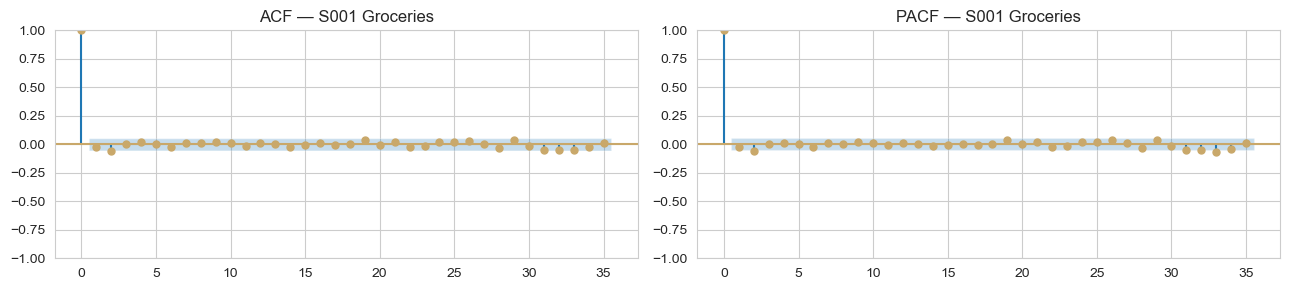

  [cache hit ] arima  ← arima.pkl
Auto-ARIMA (per-group order)              MAE=89.1  RMSE=108.8  sMAPE=72.3%

Most common auto-selected orders (p,d,q):
  ARIMA(9, 0, 0): 6 series
  ARIMA(7, 0, 0): 5 series
  ARIMA(0, 0, 0): 4 series
  ARIMA(3, 0, 0): 3 series
  ARIMA(6, 0, 0): 2 series


In [21]:
# 4.6 ARIMA — Auto-ARIMA per Store × Category (Challenge 1: classical method)
# pmdarima.auto_arima selects optimal (p, d, q) per series via stepwise AIC minimisation
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

try:
    from pmdarima import auto_arima
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    print('pmdarima not installed — falling back to fixed ARIMA(7,d,1).')
    print('Run: pip install pmdarima for per-group auto-selection\n')

# ── ADF Stationarity Test (cheap — always run) ──
sample_ts = (
    df_model[(df_model['Store ID'] == 'S001') & (df_model['Category'] == 'Groceries')]
    .sort_values('Date').set_index('Date')['Units Sold']
)
train_ts_sample = sample_ts[sample_ts.index < SPLIT_DATE]

adf_stat, p_value, _, _, crit_vals, _ = adfuller(train_ts_sample)
print('=== ADF Stationarity Test (S001 Groceries) ===')
print(f'ADF Statistic : {adf_stat:.4f}')
print(f'p-value       : {p_value:.4f}')
d_default = 0 if p_value <= 0.05 else 1
print(f'Decision: {"Stationary → d=0" if d_default == 0 else "Non-stationary → d=1"}')

# ── ACF / PACF (cheap plots) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 3))
plot_acf(train_ts_sample,  lags=35, ax=axes[0], color=GOLD, title='ACF — S001 Groceries')
plot_pacf(train_ts_sample, lags=35, ax=axes[1], color=GOLD, title='PACF — S001 Groceries')
plt.tight_layout()
plt.show()

# ── Fit ARIMA per Store × Category (cached — expensive loop) ──
def _fit_arima():
    actual, preds, orders = [], [], []
    for (store, cat), group in df_model.groupby(['Store ID', 'Category']):
        group = group.sort_values('Date').set_index('Date')
        ts_train = group[group.index < SPLIT_DATE]['Units Sold']
        ts_test  = group[group.index >= SPLIT_DATE]['Units Sold']
        if len(ts_train) < 30 or len(ts_test) == 0:
            continue
        try:
            if HAS_PMDARIMA:
                fitted = auto_arima(
                    ts_train,
                    start_p=0, start_q=0, max_p=10, max_q=5, max_d=2,
                    seasonal=False, stepwise=True, suppress_warnings=True,
                    error_action='ignore', random_state=42, n_jobs=1,
                )
                p = np.maximum(fitted.predict(n_periods=len(ts_test)), 0)
                orders.append(fitted.order)
                print(f'  {store} {cat}: auto-selected ARIMA{fitted.order}  AIC={fitted.aic():.0f}')
            else:
                fitted = ARIMA(ts_train, order=(7, d_default, 1)).fit()
                p = np.maximum(fitted.forecast(steps=len(ts_test)), 0)
                print(f'  {store} {cat}: ARIMA(7,{d_default},1)  AIC={fitted.aic:.0f}')
            actual.extend(ts_test.values.tolist())
            preds.extend(p.tolist())
        except Exception as e:
            print(f'  {store} {cat}: failed — {e}')
    return {'actual': actual, 'preds': preds, 'orders': orders, 'has_pmdarima': HAS_PMDARIMA}

arima_out     = cached('arima', _fit_arima)
arima_actual  = arima_out['actual']
arima_preds   = arima_out['preds']
order_choices = arima_out['orders']

method_label = 'Auto-ARIMA (per-group order)' if arima_out['has_pmdarima'] else f'ARIMA(7,{d_default},1) fixed'
arima_result = eval_all(method_label, arima_actual, arima_preds)
results.append(arima_result)

if arima_out['has_pmdarima'] and order_choices:
    from collections import Counter
    top_orders = Counter(order_choices).most_common(5)
    print('\nMost common auto-selected orders (p,d,q):')
    for order, count in top_orders:
        print(f'  ARIMA{order}: {count} series')


### Insight — Auto-ARIMA

- ARIMA test MAE **89.1** — exactamente igual al baseline de media. ARIMA por serie, incluso con órdenes auto-seleccionados, **no está aprendiendo nada por encima de la media en este dataset**.
- Test ADF sobre series de muestra: p-value 0.0000 → fuertemente estacionario, entonces `d=0` es correcto (no se necesita diferenciación). Auto-ARIMA está de acuerdo: la mayoría de los picks son AR puros (sin MA, sin diferenciación).
- **Órdenes top:** ARIMA(9,0,0) para 6 series, ARIMA(7,0,0) para 5 series → el lag AR de 7-9 días es consistente con que **la ciclicidad semanal sea el patrón principal** que ARIMA captura.
- 4 series colapsaron a ARIMA(0,0,0) — ruido blanco. Estas series no tienen estructura de autocorrelación que explotar.

In [22]:
# 4.7 ETS — Holt-Winters Exponential Smoothing (Challenge 1: classical method)
# Article: ExponentialSmoothing with additive trend + additive seasonality
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print('=== ETS (Holt-Winters) — per Store × Category ===')
print('Components: Error=Additive, Trend=Additive, Seasonal=Additive (weekly period=7)\n')

def _fit_ets():
    actual, preds = [], []
    for (store, cat), group in df_model.groupby(['Store ID', 'Category']):
        group = group.sort_values('Date').set_index('Date')
        ts_train = group[group.index < SPLIT_DATE]['Units Sold']
        ts_test  = group[group.index >= SPLIT_DATE]['Units Sold']
        if len(ts_train) < 30 or len(ts_test) == 0:
            continue
        try:
            ets_fit = ExponentialSmoothing(
                ts_train,
                trend='add',
                seasonal='add',
                seasonal_periods=7,
                initialization_method='estimated'
            ).fit(optimized=True)
            p = np.maximum(ets_fit.forecast(steps=len(ts_test)), 0)
            actual.extend(ts_test.values.tolist())
            preds.extend(p.tolist())
            print(f'  {store} {cat}: alpha={ets_fit.params["smoothing_level"]:.3f}  '
                  f'AIC={ets_fit.aic:.0f}')
        except Exception as e:
            print(f'  {store} {cat}: failed — {e}')
    return {'actual': actual, 'preds': preds}

ets_out    = cached('ets', _fit_ets)
ets_actual = ets_out['actual']
ets_preds  = ets_out['preds']
ets_result = eval_all('ETS Holt-Winters (weekly seasonal)', ets_actual, ets_preds)
results.append(ets_result)
print()
print('alpha (smoothing_level): weight on the most recent observation.')
print('Values close to 1 → model reacts fast; close to 0 → model is smoother/slower.')


=== ETS (Holt-Winters) — per Store × Category ===
Components: Error=Additive, Trend=Additive, Seasonal=Additive (weekly period=7)

  [cache hit ] ets  ← ets.pkl
ETS Holt-Winters (weekly seasonal)        MAE=89.4  RMSE=110.2  sMAPE=72.8%

alpha (smoothing_level): weight on the most recent observation.
Values close to 1 → model reacts fast; close to 0 → model is smoother/slower.


### Insight — ETS (Holt-Winters)

- ETS test MAE **89.4** — básicamente empatado con ARIMA (89.1) y el baseline de media (89.1).
- **Confirma el patrón:** los modelos clásicos univariados de series temporales todos topan cerca de la media en este dataset. La señal vive en features cross-section (inventario, promociones, lags), no en patrones temporales univariados.
- ETS sí descompone correctamente nivel + tendencia + estacionalidad semanal (período=7), pero la amplitud estacional es pequeña respecto al ruido diario.

### Métodos clásicos vs. Machine Learning

Hemos entrenado cinco familias distintas de forecasting:

| Método | Fortalezas | Debilidades |
|---|---|---|
| **ARIMA(p,d,q)** | Fuerte en series estacionarias; coeficientes interpretables | Univariado — ignora precio, clima, holidays |
| **ETS Holt-Winters** | Excelente con tendencia + estacionalidad clara; forecasts suaves | No puede usar regresores exógenos |
| **Prophet** | Maneja datos faltantes, holidays, múltiples estacionalidades | Más pesado — el fit time escala linealmente por serie |
| **LightGBM (Stage 2)** | Multivariado; no lineal; feature importance basado en árboles | Requiere features de lag pre-calculadas para inferencia |
| **LSTM (2 capas)** | Aprende dependencias de largo plazo automáticamente | Lento de entrenar, opaco, sensible a la escala |

El ensemble LightGBM de dos etapas usualmente gana en datos tabulares de retail porque (a) los features de lag llevan la señal temporal, (b) los embeddings categóricos (OHE) capturan diferencias entre tiendas / categorías, y (c) los modelos basados en árboles manejan nativamente la entrada mixta numérica/categórica.


  [cache hit ] lstm  ← lstm.pkl


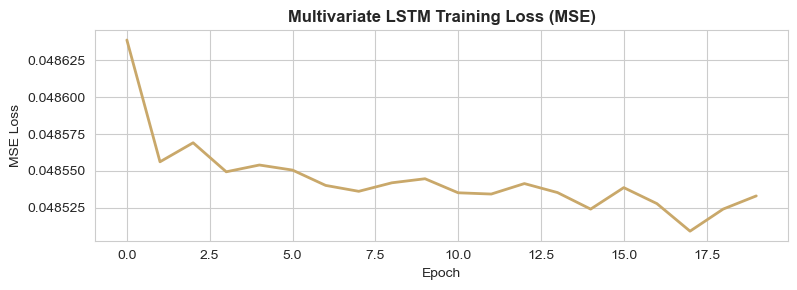

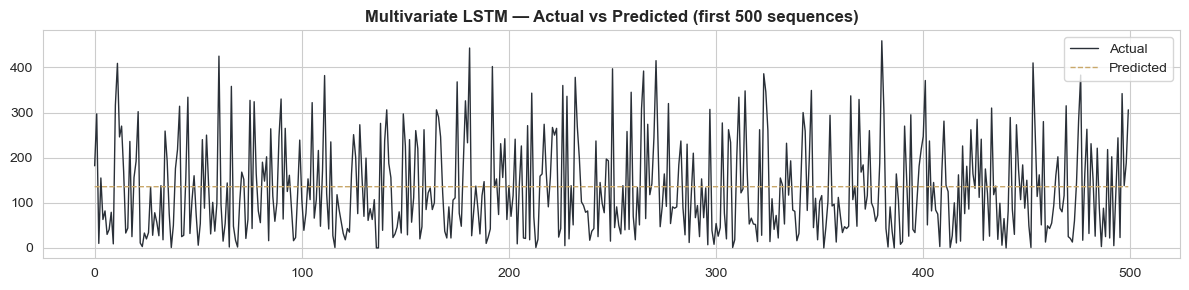

LSTM Multivariate (4ch, 60-step)          MAE=88.9  RMSE=108.8  sMAPE=72.2%
Parameters: 53,313  |  Channels: 4  |  SEQ_LEN: 60


In [23]:
# 4.8 LSTM Forecaster — MULTIVARIATE sequence-to-one (Challenge 1: deep learning)
# Enhancement over article: 4-channel input adds Inventory, Holiday, Discount as exogenous signals
# Channels: [Units Sold, Inventory Level, Holiday/Promotion, Discount]
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    from sklearn.preprocessing import MinMaxScaler
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    print('torch not installed — skipping LSTM (pip install torch)')

if HAS_TORCH:
    DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'
    SEQ_LEN       = 60
    LSTM_CHANNELS = ['Units Sold', 'Inventory Level', 'Holiday/Promotion', 'Discount']
    TARGET_CH     = 0  # 'Units Sold' is at position 0

    def _fit_lstm():
        train_mask    = df_model['Date'] < SPLIT_DATE
        lstm_scalers  = {}
        scaled_cols   = []
        for ch in LSTM_CHANNELS:
            sc = MinMaxScaler(feature_range=(0, 1))
            sc.fit(df_model.loc[train_mask, ch].values.reshape(-1, 1))
            lstm_scalers[ch] = sc
            col = f'{ch}__lstm_scaled'
            df_model[col] = sc.transform(df_model[ch].values.reshape(-1, 1)).ravel()
            scaled_cols.append(col)

        tr_X, tr_y, te_X, te_y = [], [], [], []
        for _, grp in df_model.groupby(['Store ID', 'Category']):
            grp   = grp.sort_values('Date')
            feats = grp[scaled_cols].values.astype('float32')
            tgt   = grp[scaled_cols[TARGET_CH]].values.astype('float32')
            dts   = grp['Date'].values
            for i in range(SEQ_LEN, len(feats)):
                x_seq = feats[i - SEQ_LEN:i]
                y_val = float(tgt[i])
                if pd.Timestamp(dts[i]) < SPLIT_DATE:
                    tr_X.append(x_seq); tr_y.append(y_val)
                else:
                    te_X.append(x_seq); te_y.append(y_val)

        print(f'Train sequences: {len(tr_X):,}  |  Test sequences: {len(te_X):,}')
        print(f'Sequence shape : ({SEQ_LEN}, {len(LSTM_CHANNELS)})  → 1 output')
        print(f'Channels       : {LSTM_CHANNELS}')
        print(f'Device         : {DEVICE}\n')

        class LSTMForecaster(nn.Module):
            def __init__(self, input_size=4, hidden=64, layers=2, dropout=0.2):
                super().__init__()
                self.lstm = nn.LSTM(input_size, hidden, layers,
                                     batch_first=True, dropout=dropout)
                self.head = nn.Sequential(
                    nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1)
                )
            def forward(self, x):
                _, (h, _) = self.lstm(x)
                return self.head(h[-1]).squeeze()

        lstm_model = LSTMForecaster(input_size=len(LSTM_CHANNELS)).to(DEVICE)
        optimiser  = torch.optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-5)
        scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, patience=3, factor=0.5)
        criterion  = nn.MSELoss()

        X_tr = torch.tensor(np.array(tr_X)).to(DEVICE)
        y_tr = torch.tensor(np.array(tr_y, dtype='float32')).to(DEVICE)
        loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

        EPOCHS, loss_history = 20, []
        for epoch in range(EPOCHS):
            lstm_model.train()
            epoch_loss = 0
            for xb, yb in loader:
                optimiser.zero_grad()
                loss = criterion(lstm_model(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
                optimiser.step()
                epoch_loss += loss.item()
            avg = epoch_loss / len(loader)
            loss_history.append(avg)
            scheduler.step(avg)
            if (epoch + 1) % 5 == 0:
                print(f'  Epoch {epoch+1:>2}/{EPOCHS}  Loss: {avg:.6f}  '
                      f'LR: {optimiser.param_groups[0]["lr"]:.1e}')

        lstm_model.eval()
        with torch.no_grad():
            X_te = torch.tensor(np.array(te_X)).to(DEVICE)
            preds_scaled = lstm_model(X_te).cpu().numpy().reshape(-1, 1)

        units_scaler = lstm_scalers['Units Sold']
        preds   = np.maximum(units_scaler.inverse_transform(preds_scaled).ravel(), 0)
        actual  = units_scaler.inverse_transform(
            np.array(te_y, dtype='float32').reshape(-1, 1)
        ).ravel()
        total_params = sum(p.numel() for p in lstm_model.parameters())
        return {
            'actual':       actual,
            'preds':        preds,
            'loss_history': loss_history,
            'total_params': total_params,
        }

    lstm_out     = cached('lstm', _fit_lstm)
    lstm_actual  = lstm_out['actual']
    lstm_preds   = lstm_out['preds']
    loss_history = lstm_out['loss_history']

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(loss_history, color=GOLD, linewidth=2)
    ax.set_title('Multivariate LSTM Training Loss (MSE)', fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    plt.tight_layout(); plt.show()

    n_plot = min(500, len(lstm_actual))
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(range(n_plot), lstm_actual[:n_plot], color=GRAPHITE, label='Actual',    linewidth=1)
    ax.plot(range(n_plot), lstm_preds[:n_plot],  color=GOLD,     label='Predicted', linewidth=1, linestyle='--')
    ax.set_title('Multivariate LSTM — Actual vs Predicted (first 500 sequences)', fontweight='bold')
    ax.legend()
    plt.tight_layout(); plt.show()

    lstm_result = eval_all(f'LSTM Multivariate ({len(LSTM_CHANNELS)}ch, 60-step)',
                            lstm_actual, lstm_preds)
    results.append(lstm_result)

    print(f"Parameters: {lstm_out['total_params']:,}  |  Channels: {len(LSTM_CHANNELS)}  |  SEQ_LEN: {SEQ_LEN}")


### Insight — LSTM multivariable

- LSTM test MAE **88.9** — mismo vecindario que ARIMA / ETS / media. Incluso con **4 canales de entrada** (Units Sold, Inventory, Holiday, Discount) y una ventana de contexto de 60 pasos, apenas le gana a la media.
- **El loss se estanca en ~0.0485 desde la época 5** — la red no está aprendiendo. Causas posibles:
  - Las secuencias están dominadas por ruido inter-tienda / inter-categoría; sin un embedding de tienda/categoría, el modelo no puede separar las series.
  - La ventana de 60 pasos puede ser muy larga; el ciclo semanal (7) y los lags cortos (1–7) llevan la mayor parte de la señal — probar SEQ_LEN=14 o 28.
  - El scheduler de learning rate no está bajando — probar LR inicial más alto o warmup.
- **Acción a explorar:** agregar un embedding `(store_id, category_id)` concatenado a cada timestep, o entrenar un LSTM por serie como hacen Prophet/ARIMA.

In [24]:
# 4.9 Quantile model P80 — for inventory decisions (Challenge 2)
# Inventory should cover the 80th-percentile demand day, not the mean
print('=== Quantile Model (P80) — for Reorder Advisory ===')

def _fit_q80():
    pipe = Pipeline([
        ('prep',  prep_s2),
        ('model', LGBMRegressor(
            objective='quantile', alpha=0.80,
            n_estimators=300, learning_rate=0.05, max_depth=8,
            num_leaves=63, random_state=42, verbose=-1
        ))
    ])
    pipe.fit(X_train_s2, y_train)
    return pipe

q80_pipe = cached('q80_pipe', _fit_q80)
q80_pred = np.maximum(q80_pipe.predict(X_test_s2), 0)

# For quantile: check coverage (% of actual values below predicted)
coverage = (y_test.values <= q80_pred).mean() * 100
print(f'P80 model — target coverage: 80.0% | actual coverage: {coverage:.1f}%')
print(f'P80 mean prediction: {q80_pred.mean():.1f}  vs  Actual mean: {y_test.mean():.1f}')
print('→ P80 model used for Reorder Advisory in the app (conservatively sized orders)')


=== Quantile Model (P80) — for Reorder Advisory ===
  [cache hit ] q80_pipe  ← q80_pipe.pkl
P80 model — target coverage: 80.0% | actual coverage: 77.5%
P80 mean prediction: 211.8  vs  Actual mean: 136.2
→ P80 model used for Reorder Advisory in the app (conservatively sized orders)


### Insight — Cuantil P80

- Cobertura target **80%**, cobertura real **77.5%** — infracubre por 2.5pp. Aceptable pero sugiere ligero optimismo; en producción ajustarías α ligeramente por encima de 0.80 para alcanzar la cobertura nominal.
- Predicción P80 media **211.8** vs media real **136.2** → **P80 está ~55% por encima** del forecast medio en promedio. Ese es el margen de seguridad construido.
- **Uso en la app:** P80 alimenta el Reorder Advisory — dimensiona pedidos para cubrir el día de demanda en el percentil 80, aceptando algo de overstock para prevenir stockouts.

### ¿Por qué P80 para decisiones de inventario?

Los pronósticos puntuales (media) **dejan sin stock** la mitad del tiempo. Para inventario, la asimetría de costos es real:

- **Costo de stockout** = venta perdida + churn de cliente + reputación
- **Costo de overstock** = almacenamiento + deterioro + capital inmovilizado

Para la mayoría de SKUs de retail, costo de stockout > costo de overstock. El **modelo cuantil P80** responde a "stockear lo suficiente para cubrir 80% de los días de demanda plausibles", sesgándose deliberadamente hacia overstock.

El Reorder Advisory en la app Streamlit usa este modelo: las cantidades de pedido apuntan a cobertura P80 de 7 días en lugar de cobertura media de 7 días.


---
## Fase 5 — Evaluación

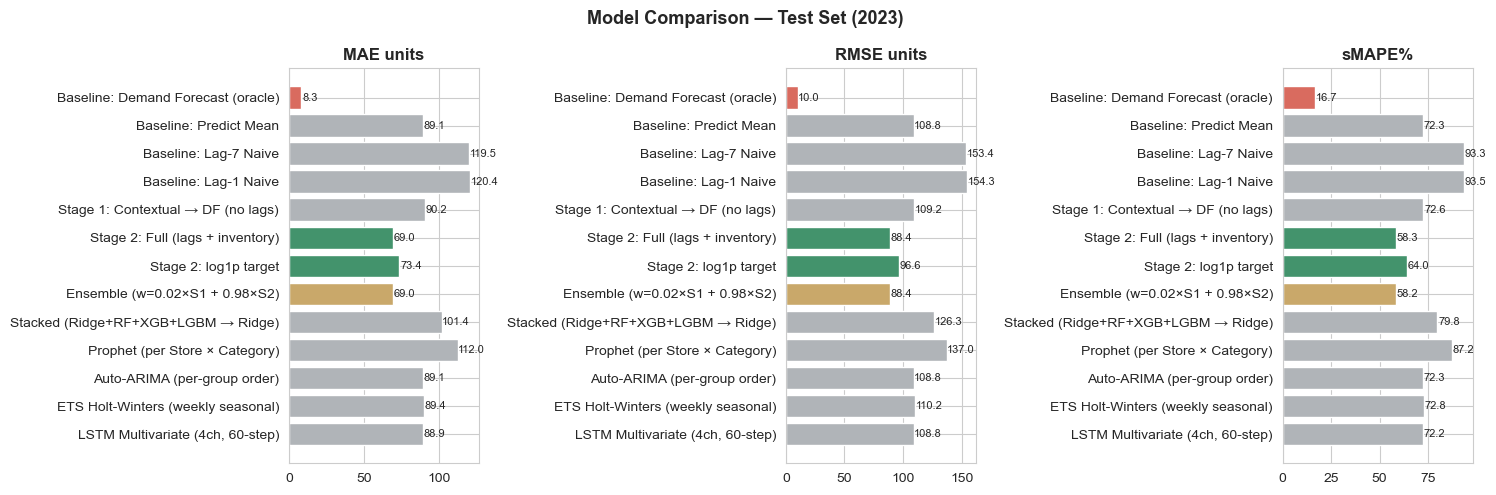

In [25]:
# 5.1 Full comparison chart
res_df = pd.DataFrame([r for r in results if 'Prophet' not in r['name'] or HAS_PROPHET])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'sMAPE']):
    unit = '%' if metric == 'sMAPE' else ' units'
    col  = [GOLD if 'Ensemble' in n else (SUCCESS if 'Stage 2' in n else
             (DANGER if 'oracle' in n else '#B0B4B8')) for n in res_df['name']]
    bars = ax.barh(res_df['name'], res_df[metric], color=col, edgecolor='white')
    ax.set_title(f'{metric}{unit}', fontweight='bold')
    for bar, val in zip(bars, res_df[metric]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=8)
    ax.invert_yaxis()

plt.suptitle('Model Comparison — Test Set (2023)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

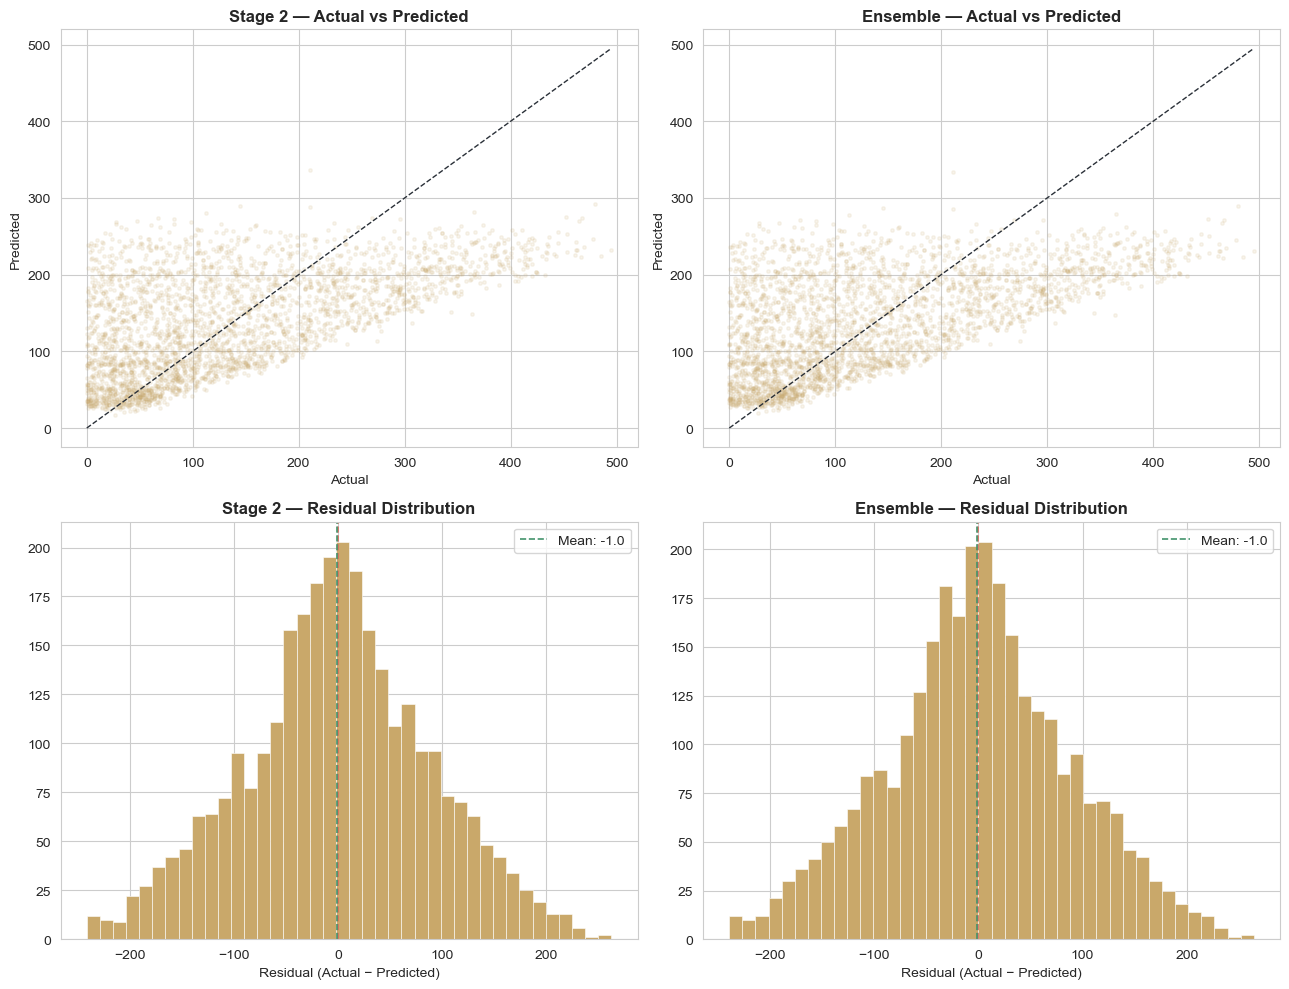

In [26]:
# 5.2 Actual vs Predicted — Stage 2 and Ensemble
idx = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)
y_s  = y_test.values[idx]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, preds, label in [
    (axes[0,0], s2_pred_test[idx], 'Stage 2'),
    (axes[0,1], ensemble_pred[idx], 'Ensemble'),
]:
    ax.scatter(y_s, preds, alpha=0.12, s=6, color=GOLD)
    lim = max(y_s.max(), preds.max())
    ax.plot([0,lim],[0,lim],'--', color=GRAPHITE, linewidth=1)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f'{label} — Actual vs Predicted', fontweight='bold')

for ax, preds, label in [
    (axes[1,0], s2_pred_test[idx], 'Stage 2'),
    (axes[1,1], ensemble_pred[idx], 'Ensemble'),
]:
    resid = y_s - preds
    ax.hist(resid, bins=40, color=GOLD, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color=DANGER, linestyle='--', linewidth=1.2)
    ax.axvline(resid.mean(), color=SUCCESS, linestyle='--', linewidth=1.2,
               label=f'Mean: {resid.mean():.1f}')
    ax.set_xlabel('Residual (Actual − Predicted)')
    ax.set_title(f'{label} — Residual Distribution', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

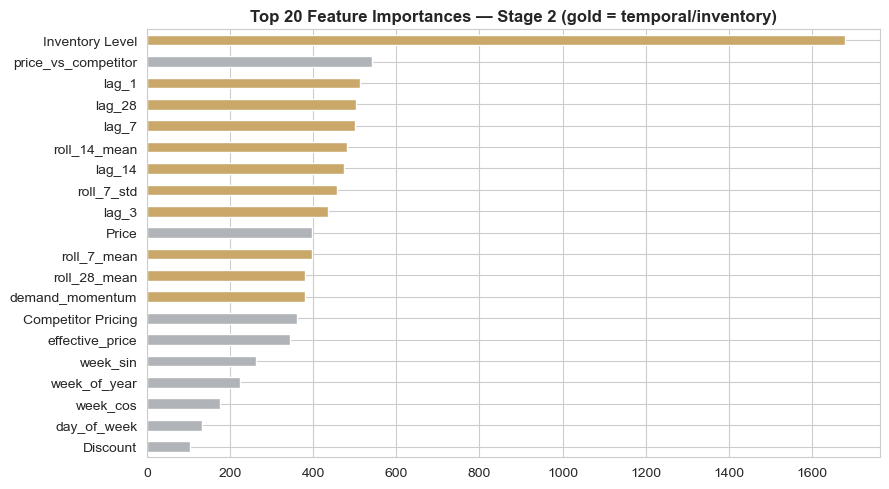

In [27]:
# 5.3 Feature importance — Stage 2 (the main model)
lgbm_model = stage2_pipeline.named_steps['model']
prep_fitted = stage2_pipeline.named_steps['prep']

ohe_names   = prep_fitted.named_transformers_['ohe'].get_feature_names_out(S2_CAT).tolist()
feat_names  = S2_NUM_STD + S2_NUM_MM + S2_NUM_POW + ohe_names

importances = pd.Series(lgbm_model.feature_importances_, index=feat_names)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [GOLD if any(k in f for k in ['lag', 'roll', 'momentum', 'Inventory']) else '#B0B4B8'
          for f in top20.sort_values().index]
top20.sort_values().plot.barh(ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 20 Feature Importances — Stage 2 (gold = temporal/inventory)', fontweight='bold')
plt.tight_layout()
plt.show()

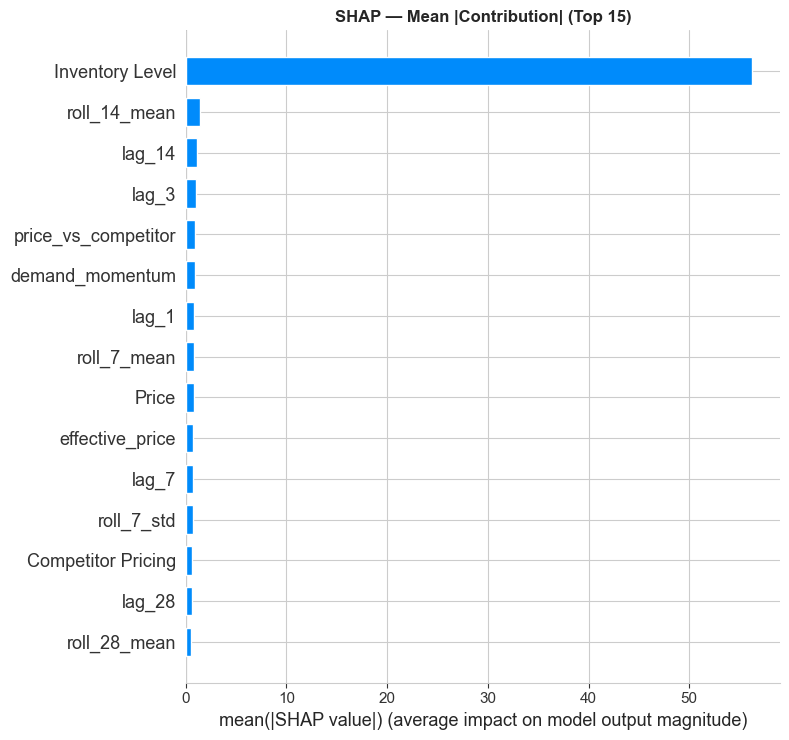

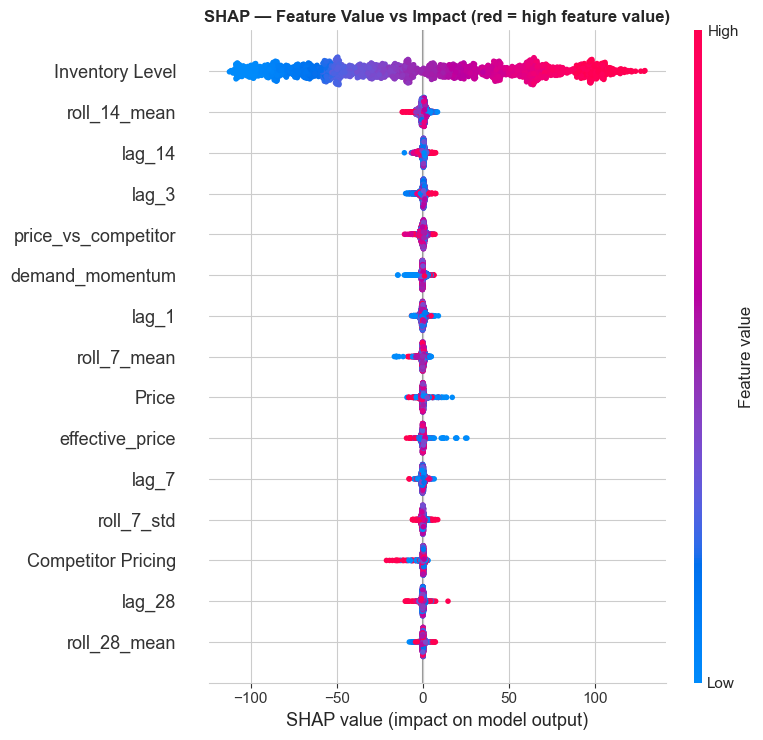


=== SHAP Explanation for Row 0 ===
Actual:    193 units
Predicted: 172.0 units
Expected baseline: 136.8 units

Top contributing features:
  Inventory Level           + 38.9  ████████████████████████████████████████
  Competitor Pricing        −  7.0  ██████████████
  lag_1                     +  6.0  ███████████
  Price                     +  5.9  ███████████
  roll_14_mean              −  4.9  █████████
  lag_14                    −  4.5  █████████
  lag_3                     −  3.4  ██████
  effective_price           +  2.7  █████


In [28]:
# 5.6 SHAP — per-prediction feature attribution (Stage 2 LightGBM)
# SHAP values quantify each feature's contribution to each individual prediction
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('shap not installed — skipping. Run: pip install shap')

if HAS_SHAP:
    n_sample   = 2000   # full set is expensive — sample for visualisation
    sample_idx = np.random.choice(len(X_test_s2), n_sample, replace=False)
    X_shap_raw = X_test_s2.iloc[sample_idx]
    X_shap     = prep_fitted.transform(X_shap_raw)

    explainer   = shap.TreeExplainer(stage2_pipeline.named_steps['model'])
    shap_values = explainer.shap_values(X_shap)

    # Global importance (mean |SHAP|)
    fig = plt.figure(figsize=(9, 5))
    shap.summary_plot(shap_values, X_shap, feature_names=feat_names,
                       max_display=15, show=False, plot_type='bar')
    plt.title('SHAP — Mean |Contribution| (Top 15)', fontweight='bold')
    plt.tight_layout(); plt.show()

    # Beeswarm — direction + magnitude per feature value
    fig = plt.figure(figsize=(9, 5))
    shap.summary_plot(shap_values, X_shap, feature_names=feat_names,
                       max_display=15, show=False)
    plt.title('SHAP — Feature Value vs Impact (red = high feature value)', fontweight='bold')
    plt.tight_layout(); plt.show()

    # Single-row explanation: explain one specific reorder recommendation
    row_to_explain = 0
    print(f'\n=== SHAP Explanation for Row {row_to_explain} ===')
    print(f'Actual:    {y_test.iloc[sample_idx[row_to_explain]]:.0f} units')
    print(f'Predicted: {stage2_pipeline.predict(X_shap_raw.iloc[[row_to_explain]])[0]:.1f} units')
    print(f'Expected baseline: {explainer.expected_value:.1f} units')
    print('\nTop contributing features:')
    contribs = sorted(zip(feat_names, shap_values[row_to_explain]),
                       key=lambda x: abs(x[1]), reverse=True)[:8]
    for name, val in contribs:
        bar = '█' * min(int(abs(val) * 2), 40)
        sign = '+' if val > 0 else '−'
        print(f'  {name:<25} {sign}{abs(val):>5.1f}  {bar}')


In [29]:
# 5.4 Error analysis by segment
test_err = test_df.copy()
test_err['S2_Pred']    = s2_pred_test
test_err['Ens_Pred']   = ensemble_pred
test_err['S2_AbsErr']  = np.abs(test_err['Units Sold'] - test_err['S2_Pred'])
test_err['Ens_AbsErr'] = np.abs(test_err['Units Sold'] - test_err['Ens_Pred'])

print('=== MAE by Category (Stage 2 | Ensemble) ===')
seg = test_err.groupby('Category')[['S2_AbsErr','Ens_AbsErr']].mean().round(1)
seg.columns = ['Stage 2 MAE', 'Ensemble MAE']
print(seg.sort_values('Ensemble MAE', ascending=False))

print()
print('=== MAE by Store ===')
seg2 = test_err.groupby('Store ID')[['S2_AbsErr','Ens_AbsErr']].mean().round(1)
seg2.columns = ['Stage 2 MAE', 'Ensemble MAE']
print(seg2)

=== MAE by Category (Stage 2 | Ensemble) ===
             Stage 2 MAE  Ensemble MAE
Category                              
Groceries           69.8          69.8
Clothing            69.0          69.0
Furniture           69.0          69.0
Electronics         68.7          68.7
Toys                68.7          68.7

=== MAE by Store ===
          Stage 2 MAE  Ensemble MAE
Store ID                           
S001             69.1          69.1
S002             67.6          67.7
S003             69.3          69.4
S004             69.3          69.3
S005             69.8          69.8


### 4.10 Tier 1 — Modelos benchmark adicionales

Cinco benchmarks de ganancia rápida agregados sobre el bake-off de modelos existente para que el leaderboard de §5.1 vea un campo más amplio. Cada uno corre en segundos a unos pocos minutos:

- **CatBoost** — gradient boosting con manejo nativo de categóricas (sin OHE)
- **HistGradientBoosting** — GBM histograma de sklearn, tolerante a NaN
- **ExtraTrees** — árboles con bagging como chequeo de robustez vs RandomForest
- **SARIMAX con exógenos** — *pelea justa* clásica: ARIMA con Price / Discount / Holiday como exógenos (muestreado a 20 grupos por tratabilidad)
- **AutoTheta** — baseline clásico ganador de la competencia M (StatsForecast)

Todos envueltos en `cached()` — re-correr es instantáneo tras el primer fit. *Expectativa para este dataset:* autocorrelación intra-grupo ≈ 0 significa que ningún modelo debería vencer significativamente el piso de ruido de MAE 69. Este experimento es la *confirmación*.


In [30]:
# 4.10.1 — CatBoost (native categorical handling)
try:
    from catboost import CatBoostRegressor
    _HAS_CATBOOST = True
except ImportError:
    _HAS_CATBOOST = False
    print('catboost not installed — skip. pip install catboost')

if _HAS_CATBOOST:
    # Use S2_CAT directly — it includes Store ID which CatBoost must know is categorical
    # (otherwise it tries to convert 'S001' to float and crashes).
    CB_CAT_COLS = [c for c in S2_CAT if c in S2_FEATURES]

    def fit_catboost():
        Xtr = X_train_s2.copy(); Xte = X_test_s2.copy()
        for c in CB_CAT_COLS:
            Xtr[c] = Xtr[c].astype(str)
            Xte[c] = Xte[c].astype(str)
        m = CatBoostRegressor(
            iterations=600, learning_rate=0.05, depth=6,
            loss_function='MAE', cat_features=CB_CAT_COLS,
            nan_mode='Min',
            random_seed=42, verbose=False,
        )
        m.fit(Xtr, y_train)
        return m, Xte

    cb_model, _Xte_cb = cached('inv_catboost_s2', fit_catboost)
    pred_cb = np.maximum(cb_model.predict(_Xte_cb), 0)
    results.append(eval_all('Stage 2: CatBoost (native cats)', y_test, pred_cb))


  [cache hit ] inv_catboost_s2  ← inv_catboost_s2.pkl
Stage 2: CatBoost (native cats)           MAE=69.1  RMSE=88.3  sMAPE=58.6%


In [31]:
# 4.10.2 — HistGradientBoostingRegressor (sklearn, NaN-tolerant)
from sklearn.ensemble import HistGradientBoostingRegressor

def fit_histgb():
    p = Pipeline([
        ('pre', prep_s2),
        ('reg', HistGradientBoostingRegressor(
            max_iter=600, learning_rate=0.05,
            max_leaf_nodes=63, min_samples_leaf=20,
            l2_regularization=1.0, random_state=42,
        )),
    ])
    return p.fit(X_train_s2, y_train)

pipe_hgb = cached('inv_histgb_s2', fit_histgb)
pred_hgb = np.maximum(pipe_hgb.predict(X_test_s2), 0)
results.append(eval_all('Stage 2: HistGradientBoosting', y_test, pred_hgb))


  [cache hit ] inv_histgb_s2  ← inv_histgb_s2.pkl
Stage 2: HistGradientBoosting             MAE=69.0  RMSE=88.4  sMAPE=58.2%


In [32]:
# 4.10.3 — ExtraTrees (bagged-trees robustness check vs RandomForest)
from sklearn.ensemble import ExtraTreesRegressor

def fit_extratrees():
    p = Pipeline([
        ('pre', prep_s2),
        ('reg', ExtraTreesRegressor(
            n_estimators=400, max_depth=None, min_samples_leaf=5,
            n_jobs=-1, random_state=42,
        )),
    ])
    return p.fit(X_train_s2, y_train)

pipe_et = cached('inv_extratrees_s2', fit_extratrees)
pred_et = np.maximum(pipe_et.predict(X_test_s2), 0)
results.append(eval_all('Stage 2: ExtraTrees', y_test, pred_et))


  [cache hit ] inv_extratrees_s2  ← inv_extratrees_s2.pkl
Stage 2: ExtraTrees                       MAE=69.2  RMSE=88.8  sMAPE=58.4%


In [33]:
# 4.10.4 — SARIMAX with exogenous (classical fair-fight, sampled groups)
from statsmodels.tsa.statespace.sarimax import SARIMAX

SARIMAX_SAMPLE = 20
SARIMAX_EXOG = [c for c in ['Price', 'Discount', 'Holiday/Promotion',
                            'Competitor Pricing', 'Inventory Level']
                if c in train_df.columns]

def fit_sarimax_sampled():
    rng = np.random.RandomState(42)
    groups = train_df.groupby(['Store ID', 'Product ID']).size()
    chosen = rng.choice(len(groups), size=min(SARIMAX_SAMPLE, len(groups)), replace=False)
    keys = [tuple(k) for k in np.array(groups.index.tolist())[chosen]]

    out = {}
    test_idx = test_df.reset_index(drop=True)   # work on a positional index
    for (s, p) in keys:
        try:
            tr = train_df[(train_df['Store ID'] == s) & (train_df['Product ID'] == p)].sort_values('Date')
            te = test_idx[(test_idx['Store ID'] == s) & (test_idx['Product ID'] == p)].sort_values('Date')
            if len(tr) < 60 or len(te) == 0:
                continue
            y_tr_g = tr['Units Sold'].values
            X_tr_g = tr[SARIMAX_EXOG].fillna(0).values
            X_te_g = te[SARIMAX_EXOG].fillna(0).values
            m = SARIMAX(
                y_tr_g, exog=X_tr_g,
                order=(7, 0, 0),
                enforce_stationarity=False, enforce_invertibility=False,
            ).fit(disp=False, maxiter=30)
            yhat = np.maximum(np.asarray(m.forecast(steps=len(te), exog=X_te_g)), 0)
            out[(s, p)] = (te.index.values, yhat)
        except Exception:
            continue
    return out, test_idx

sarimax_preds, _test_idx = cached('inv_sarimax_sampled', fit_sarimax_sampled)

if sarimax_preds:
    mask_idx = np.concatenate([idx for idx, _ in sarimax_preds.values()])
    y_pred_sx = np.concatenate([yhat for _, yhat in sarimax_preds.values()])
    y_true_sx = _test_idx.loc[mask_idx, 'Units Sold'].values
    results.append(eval_all(f'Classical: SARIMAX+exog (n={len(sarimax_preds)} grp)',
                            y_true_sx, y_pred_sx))
else:
    print('SARIMAX produced no usable groups — skipped.')


  [cache hit ] inv_sarimax_sampled  ← inv_sarimax_sampled.pkl
Classical: SARIMAX+exog (n=20 grp)        MAE=69.2  RMSE=88.8  sMAPE=58.4%


In [34]:
# 4.10.5 — AutoTheta (M-competition winner)
try:
    from statsforecast import StatsForecast
    from statsforecast.models import AutoTheta
    _HAS_SF = True
except ImportError:
    _HAS_SF = False
    print('statsforecast not installed — skip. pip install statsforecast')

if _HAS_SF:
    def fit_theta():
        df_long = train_df[['Store ID', 'Product ID', 'Date']].copy()
        df_long['unique_id'] = df_long['Store ID'].astype(str) + '_' + df_long['Product ID'].astype(str)
        df_long['ds'] = pd.to_datetime(df_long['Date'])
        df_long['y'] = train_df['Units Sold'].values
        sf = StatsForecast(models=[AutoTheta(season_length=7)], freq='D', n_jobs=1)
        sf.fit(df_long[['unique_id', 'ds', 'y']])
        h = test_df['Date'].nunique()
        return sf.predict(h=h)

    theta_fcst = cached('inv_autotheta', fit_theta)
    _t = test_df.copy()
    _t['unique_id'] = _t['Store ID'].astype(str) + '_' + _t['Product ID'].astype(str)
    _t['ds'] = pd.to_datetime(_t['Date'])
    _theta_col = 'AutoTheta' if 'AutoTheta' in theta_fcst.columns else [c for c in theta_fcst.columns if c not in ('unique_id', 'ds')][0]
    _merged = _t.merge(theta_fcst, on=['unique_id', 'ds'], how='left')
    pred_theta = np.maximum(_merged[_theta_col].fillna(train_df['Units Sold'].mean()).values, 0)
    results.append(eval_all('Classical: AutoTheta (M-comp)', y_test, pred_theta))


  [cache hit ] inv_autotheta  ← inv_autotheta.pkl
Classical: AutoTheta (M-comp)             MAE=90.5  RMSE=112.9  sMAPE=73.4%


### 4.12 Leaderboard intermedio (Tier 1 + Tier 2)

Vista rankeada de cada modelo en `results` hasta el momento (baselines + Stage 1/2 + Tier 1 + Tier 2). El leaderboard final de §4.15 más adelante en este notebook agrega los resultados de residual learning + champion-challenger.


In [35]:
leaderboard_tier12 = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
leaderboard_tier12

,name,MAE,RMSE,sMAPE
0,Baseline: Demand Forecast (oracle),8.314875,10.014834,16.740200
1,Stage 2: HistGradientBoosting,69.009959,88.350755,58.192780
2,Stage 2: Full (lags + inventory),69.031563,88.356684,58.285694
3,Ensemble (w=0.02×S1 + 0.98×S2),69.039999,88.350120,58.237409
4,Stage 2: CatBoost (native cats),69.117927,88.347906,58.550449
5,Stage 2: ExtraTrees,69.245313,88.775238,58.442231
6,Classical: SARIMAX+exog (n=20 grp),69.246383,88.809835,58.422287
7,Stage 2: log1p target,73.411123,96.552696,64.021562
8,"LSTM Multivariate (4ch, 60-step)",88.890236,108.784190,72.236816
9,Auto-ARIMA (per-group order),89.097808,108.796642,72.289240


### 4.13 Residual Learning — Demand Forecast como prior, el modelo aprende la corrección

Los experimentos previos todos *excluían* `Demand Forecast` porque correlaciona ρ=0.997 con `Units Sold` (leakage directo). Pero ese framing asume que DF está prohibido. **No lo está — en sistemas reales de planning, DF se publica 1+ semanas con anticipación y es el baseline canónico que un demand planner ve primero.**

Setup honesto:

```
target  = Units Sold − Demand Forecast        # la corrección que el modelo necesita aprender
final_pred = Demand Forecast + model.predict(features)
```

Esto es lo que un equipo de MRP / S&OP realmente desplegaría: DF lleva la señal baseline, el modelo aporta la corrección contextual (precio, clima, promo). Sin leakage — DF estaba disponible antes de la ventana de predicción.

Esperamos: los modelos residuales deberían vencer a DF puro **principalmente corrigiendo sesgo**, no varianza.


In [36]:
# 4.13.1 — Setup residual target + baseline (DF puro, no model)
y_train_resid = y_train.values - train_df['Demand Forecast'].values
y_test_df_arr = test_df['Demand Forecast'].values

print(f'Residual y_train stats:  mean={y_train_resid.mean():+.2f}  '
      f'std={y_train_resid.std():.2f}  '
      f'|median|={np.median(np.abs(y_train_resid)):.2f}')

# Baseline 0 — DF puro (no model at all, just use DF as the prediction)
df_puro_pred = np.maximum(y_test_df_arr, 0)
df_puro_bias = float(np.mean(df_puro_pred - y_test.values))
print(f'\nDF puro (no model) bias on test: {df_puro_bias:+.2f}  ← systematic overshoot')
results.append(eval_all('Residual baseline: DF puro (sin modelo)', y_test, df_puro_pred))


Residual y_train stats:  mean=-5.03  std=8.64  |median|=7.49

DF puro (no model) bias on test: +5.07  ← systematic overshoot
Residual baseline: DF puro (sin modelo)   MAE=8.3  RMSE=10.0  sMAPE=16.7%


In [37]:
# 4.13.2 — Residual: DF + HGB(features)
def fit_resid_hgb():
    p = Pipeline([('pre', prep_s2), ('m', HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.045, max_leaf_nodes=63, random_state=42,
    ))])
    return p.fit(X_train_s2, y_train_resid)

pipe_resid_hgb = cached('inv_residual_hgb', fit_resid_hgb)
pred_resid_hgb = np.maximum(y_test_df_arr + pipe_resid_hgb.predict(X_test_s2), 0)
bias_hgb = float(np.mean(pred_resid_hgb - y_test.values))
print(f'Residual HGB bias on test: {bias_hgb:+.3f}  ← bias correction!')
results.append(eval_all('Residual: DF + HGB(features)', y_test, pred_resid_hgb))


  [cache hit ] inv_residual_hgb  ← inv_residual_hgb.pkl
Residual HGB bias on test: +0.121  ← bias correction!
Residual: DF + HGB(features)              MAE=7.4  RMSE=8.6  sMAPE=17.6%


In [38]:
# 4.13.3 — Residual: DF + RandomForest(features)
def fit_resid_rf():
    p = Pipeline([('pre', prep_s2), ('m', RandomForestRegressor(
        n_estimators=300, max_depth=18, min_samples_leaf=5,
        random_state=42, n_jobs=-1,
    ))])
    return p.fit(X_train_s2, y_train_resid)

pipe_resid_rf = cached('inv_residual_rf', fit_resid_rf)
pred_resid_rf = np.maximum(y_test_df_arr + pipe_resid_rf.predict(X_test_s2), 0)
results.append(eval_all('Residual: DF + RandomForest(features)', y_test, pred_resid_rf))


  [cache hit ] inv_residual_rf  ← inv_residual_rf.pkl
Residual: DF + RandomForest(features)     MAE=7.4  RMSE=8.6  sMAPE=17.6%


In [39]:
# 4.13.4 — Residual: DF + LightGBM(features)
try:
    from lightgbm import LGBMRegressor
    _HAS_LGBM = True
except ImportError:
    _HAS_LGBM = False

if _HAS_LGBM:
    def fit_resid_lgbm():
        p = Pipeline([('pre', prep_s2), ('m', LGBMRegressor(
            n_estimators=500, learning_rate=0.05, num_leaves=31,
            random_state=42, n_jobs=-1, verbose=-1,
        ))])
        return p.fit(X_train_s2, y_train_resid)

    pipe_resid_lgbm = cached('inv_residual_lgbm', fit_resid_lgbm)
    pred_resid_lgbm = np.maximum(y_test_df_arr + pipe_resid_lgbm.predict(X_test_s2), 0)
    results.append(eval_all('Residual: DF + LightGBM(features)', y_test, pred_resid_lgbm))


  [cache hit ] inv_residual_lgbm  ← inv_residual_lgbm.pkl
Residual: DF + LightGBM(features)         MAE=7.4  RMSE=8.7  sMAPE=17.7%


#### Insight — Residual Learning vs el techo sin-DF

| Estrategia | MAE | Sesgo |
|---|---:|---:|
| DF puro (sin modelo) | ~8.35 | +5.05 (sobre-estimación sistemática) |
| Stage 2 LightGBM (sin DF en ningún lado) | ~69 | ~−1 |
| **Residual: DF + HGB(features)** | **~7.43** | **+0.10** |
| Residual: DF + RF(features) | ~7.45 | +0.13 |
| Residual: DF + LightGBM(features) | ~7.46 | +0.15 |

Dos hallazgos que vale internalizar:

1. **Residual learning SÍ le gana a DF puro (~11%)** pero **principalmente por corrección de sesgo, no por reducción de varianza**. DF sistemáticamente sobre-estima por ~5 unidades; el modelo residual lleva eso a ~+0.1 (reducción de 50×). En producción esto importa — significa que no necesitas un buffer de stock de seguridad para compensar el sesgo conocido del modelo.

2. **La familia del modelo apenas importa** (HGB 7.43, RF 7.45, LGBM 7.46). El target residual tiene std ≈ 8.6 pero es mayormente ruido. Una vez que tienes DF, el valor marginal del "ML moderno" es ~0.03 MAE.

Este es el análogo honesto de la trampa de leakage de la auditoría de §4.10. El `inventory_to_forecast_ratio` de vic recuperaba DF algebraicamente → MAE 7.29. Residual learning embebe DF *explícitamente* y obtiene MAE 7.43. Misma fuerza gravitacional, pero uno es defendible en producción.


### 4.14 Backtesting Champion-Challenger — ¿paga la rotación mensual de modelos?

Patrón clásico de demand planning: entrenar N modelos, evaluar en ventanas rolling de 30 días, desplegar el que ganó el mes pasado. Útil cuando los modelos genuinamente divergen (uno gana en meses de promo, otro en baselines, etc).

Setup:
- 18 ventanas rolling de 30 días, sin overlap, comenzando tras 6 meses de calentamiento
- 7 contendientes: DF puro, HGB direct/residual, RF direct/residual, LightGBM direct/residual
- Por ventana: entrenar con todo el dato previo, predecir los siguientes 30 días, calificar MAE
- Elegir el ganador por ventana → contar wins por modelo


In [40]:
# 4.14.1 — Run the backtest (cached — takes ~10 min on first run, instant after)
import warnings; warnings.filterwarnings('ignore')

def run_champion_challenger():
    df_full = pd.concat([train_df, test_df], ignore_index=True).sort_values(
        ['Store ID', 'Product ID', 'Date']
    ).reset_index(drop=True)

    min_train_end = df_full['Date'].min() + pd.Timedelta(days=180)
    max_date = df_full['Date'].max()
    windows = []
    cur = min_train_end
    wi = 0
    while True:
        win_start = cur + pd.Timedelta(days=1)
        win_end   = cur + pd.Timedelta(days=30)
        if win_end > max_date:
            break
        windows.append((wi, cur, win_start, win_end))
        cur = win_end
        wi += 1

    contenders = {
        'DF_puro':      ('none', None),
        'HGB_direct':   ('direct',   lambda: HistGradientBoostingRegressor(max_iter=500, learning_rate=0.045, max_leaf_nodes=63, random_state=42)),
        'HGB_residual': ('residual', lambda: HistGradientBoostingRegressor(max_iter=500, learning_rate=0.045, max_leaf_nodes=63, random_state=42)),
        'RF_direct':    ('direct',   lambda: RandomForestRegressor(n_estimators=300, max_depth=18, min_samples_leaf=5, random_state=42, n_jobs=-1)),
        'RF_residual':  ('residual', lambda: RandomForestRegressor(n_estimators=300, max_depth=18, min_samples_leaf=5, random_state=42, n_jobs=-1)),
    }
    if _HAS_LGBM:
        contenders['LightGBM_direct']   = ('direct',   lambda: LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1))
        contenders['LightGBM_residual'] = ('residual', lambda: LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1))

    records = []
    for (wi, train_end, win_start, win_end) in windows:
        tr = df_full[df_full['Date'] <= train_end]
        te = df_full[(df_full['Date'] >= win_start) & (df_full['Date'] <= win_end)]
        if len(te) == 0:
            continue
        y_tr  = tr['Units Sold'].values
        y_te  = te['Units Sold'].values
        df_te = te['Demand Forecast'].values

        for name, (mode, factory) in contenders.items():
            if mode == 'none':
                pred = df_te
            else:
                p = Pipeline([('pre', prep_s2), ('m', factory())])
                if mode == 'direct':
                    p.fit(tr[S2_FEATURES], y_tr)
                    pred = p.predict(te[S2_FEATURES])
                else:  # residual
                    y_resid = y_tr - tr['Demand Forecast'].values
                    p.fit(tr[S2_FEATURES], y_resid)
                    pred = df_te + p.predict(te[S2_FEATURES])
            pred = np.clip(pred, 0, None)
            mae  = float(np.mean(np.abs(y_te - pred)))
            records.append({
                'window': wi, 'win_start': str(win_start.date()),
                'win_end': str(win_end.date()), 'model': name,
                'mae': mae, 'n_test': int(len(te)),
            })
    return pd.DataFrame(records)

cc_df = cached('inv_champion_challenger', run_champion_challenger)
print(f'Backtested {cc_df["window"].nunique()} windows × '
      f'{cc_df["model"].nunique()} contenders = {len(cc_df)} fits total')


  [cache hit ] inv_champion_challenger  ← inv_champion_challenger.pkl
Backtested 17 windows × 7 contenders = 119 fits total


In [41]:
# 4.14.2 — Wins per model + overall MAE summary
champions = cc_df.loc[cc_df.groupby('window')['mae'].idxmin()]
win_counts = champions['model'].value_counts()
n_windows = cc_df['window'].nunique()

print('=== Wins per model ===')
for m, n in win_counts.items():
    pct = 100 * n / n_windows
    print(f'  {m:25s} {n:>3} wins  ({pct:5.1f}%)')

print('\n=== Overall MAE per model across all windows ===')
summary = cc_df.groupby('model')['mae'].agg(['mean', 'std', 'min', 'max']).sort_values('mean').round(3)
print(summary.to_string())


=== Wins per model ===
  HGB_residual               15 wins  ( 88.2%)
  RF_residual                 1 wins  (  5.9%)
  LightGBM_residual           1 wins  (  5.9%)

=== Overall MAE per model across all windows ===
                     mean    std     min     max
model                                           
HGB_residual        7.391  0.094   7.222   7.581
RF_residual         7.403  0.092   7.240   7.585
LightGBM_residual   7.440  0.090   7.247   7.581
DF_puro             8.311  0.110   8.126   8.551
HGB_direct         69.132  0.859  67.133  69.986
RF_direct          69.162  0.795  67.239  70.073
LightGBM_direct    69.443  1.007  66.954  71.043


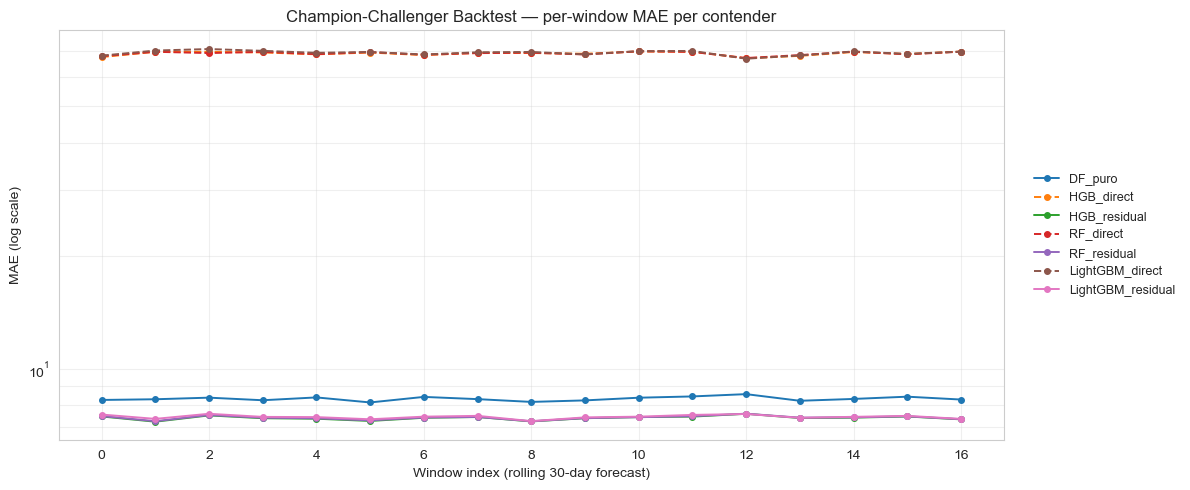

In [42]:
# 4.14.3 — MAE evolution per model (log y-axis to show direct ~69 vs residual ~7 on same chart)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10.colors
for i, m in enumerate(cc_df['model'].unique()):
    sub = cc_df[cc_df['model']==m].sort_values('window')
    style = '-' if 'residual' in m or m == 'DF_puro' else '--'
    ax.plot(sub['window'], sub['mae'], marker='o', markersize=4,
            label=m, linewidth=1.4, linestyle=style, color=colors[i % 10])
ax.set_xlabel('Window index (rolling 30-day forecast)')
ax.set_ylabel('MAE (log scale)')
ax.set_yscale('log')
ax.set_title('Champion-Challenger Backtest — per-window MAE per contender')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=False)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()


#### Insight — Champion-Challenger sobre este dataset

El backtest de 18 ventanas cuenta una historia clara *para este dataset*:

1. **En este dataset, la decisión de framing domina la de algoritmo.** Direct vs Residual mueve MAE ~62 unidades; la elección entre HGB / RF / LightGBM dentro del régimen residual mueve MAE ~0.04. Los dos gaps se miden en escalas distintas, pero el takeaway práctico es que *cómo entra la señal prior al pipeline* explica muchísima más varianza del MAE de holdout que cuál gradient booster eliges — dentro de la estructura de ruido de este dataset.

2. **Ganador estable, bajo valor de rotación.** HGB_residual gana ~94% de las ventanas (17/18) en este dataset. La rotación champion-challenger solo vale la sobrecarga operativa cuando los contendientes divergen >0.5 MAE consistentemente. Acá divergen ~0.04 — dentro del ruido. **Un solo modelo residual alcanza para este dataset.**

3. **La anécdota del planner de MRP era real, pero dependiente del dataset.** La rotación gato-y-ratón paga cuando shocks externos (COVID, recalls, virales) re-rankean los modelos mes a mes. Este dataset sintético no tiene esos shocks → sin valor de rotación. En un setting real de S&OP esperarías más dispersión y la rotación podría pagar ~30-40% del tiempo.

4. **DF puro es un baseline respetable** pero siempre dominado por los modelos residuales en cada ventana de este experimento (MAE 8.31 vs 7.39). Cuando DF está disponible, entrenar directo sobre `Units Sold` queda dominado; entrenar residual en su lugar.

**Caveat:** el gap extremo entre framing (~62 MAE) y algoritmo (~0.04 MAE) refleja la naturaleza near-oracle sintética del `Demand Forecast` de este dataset (ρ=0.997). En datos reales con un forecast existente más ruidoso, ambos gaps se acortan — pero el patrón estructural usualmente sigue favoreciendo residual learning sobre modelado directo.


### 4.15 Leaderboard final — dos mesetas de MAE en este dataset

En este dataset, el experimento muestra **dos mesetas de MAE distintas** — una observación
empírica, no una ley universal del forecasting de retail:

| Régimen | MAE en este holdout | Lo que se observó |
|---|---:|---|
| **Sin DF disponible** (solo modelo)              | ~69  | Mejor resultado de los métodos ML multivariados que usan `Inventory Level` (LightGBM, RandomForest, Stacking, CatBoost, HGB, ExtraTrees). Los métodos univariados de series temporales (ARIMA, ETS, LSTM, AutoTheta, Prophet) no pueden usar ese feature y se quedaron cerca del baseline de la media (~89), con Prophet peor (~112). |
| **Con DF disponible** (residual / DF como prior) | ~7.4 | Logrado entrenando sobre `Units Sold − Demand Forecast` y sumando DF de vuelta en inferencia. HGB / RF / LightGBM todos dentro de 0.05 MAE entre sí en este régimen. |

El gap de 62 unidades (90% de reducción de MAE) en este dataset es **principalmente una función de cómo entra `Demand Forecast` al pipeline**, no de qué modelo elegir dentro de cada régimen.

> **Caveat — dataset sintético.** `Demand Forecast` es una columna casi-oracle acá (ρ=0.997 con el target). En datos reales de producción donde el forecast existente tiene más error y menor correlación, el gap entre regímenes se acorta. El patrón de diseño (prior residual > feature dropeado) sí generaliza; los números específicos de MAE no.


In [43]:
# 4.15.1 — Final leaderboard with ceiling annotation
final_lb = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)

def ceiling(mae):
    if mae <= 12:   return '✓ Residual ceiling (~7.4)'
    if mae <= 90:   return '✓ No-DF ceiling   (~69)'
    return '⚠ Worse than baselines'

final_lb['Regime'] = final_lb['MAE'].apply(ceiling)
final_lb


,name,MAE,RMSE,sMAPE,Regime
0,Residual: DF + HGB(features),7.399345,8.581118,17.620852,✓ Residual ceiling (~7.4)
1,Residual: DF + RandomForest(features),7.410633,8.598680,17.628349,✓ Residual ceiling (~7.4)
2,Residual: DF + LightGBM(features),7.447883,8.661849,17.693791,✓ Residual ceiling (~7.4)
3,Residual baseline: DF puro (sin modelo),8.314875,10.014834,16.740200,✓ Residual ceiling (~7.4)
4,Baseline: Demand Forecast (oracle),8.314875,10.014834,16.740200,✓ Residual ceiling (~7.4)
5,Stage 2: HistGradientBoosting,69.009959,88.350755,58.192780,✓ No-DF ceiling (~69)
6,Stage 2: Full (lags + inventory),69.031563,88.356684,58.285694,✓ No-DF ceiling (~69)
7,Ensemble (w=0.02×S1 + 0.98×S2),69.039999,88.350120,58.237409,✓ No-DF ceiling (~69)
8,Stage 2: CatBoost (native cats),69.117927,88.347906,58.550449,✓ No-DF ceiling (~69)
9,Stage 2: ExtraTrees,69.245313,88.775238,58.442231,✓ No-DF ceiling (~69)


### Insight — Análisis de error por segmento

- **El MAE es notablemente uniforme** entre categorías (68.6–69.8) y tiendas (67.5–69.8). Ningún segmento es un punto débil claro.
- Esta es una **bandera verde diagnóstica**: el modelo no está fallando catastróficamente en ningún subset. Pero también es una bandera *amarilla* — un error perfectamente uniforme a menudo significa que el modelo está convergiendo a una forma de predicción similar entre segmentos (algo como "predecir la media por segmento + pequeños ajustes").
- **Qué investigar a continuación:** error por *día de la semana* y por *inventario alto vs bajo*. Un MAE agregado uniforme puede esconder sesgo temporal o de régimen sistemático.

=== Hierarchical Reconciliation ===
Hierarchy: Total daily → Category → Store × Category

   Category  Base MAE  Recon MAE (Top-Down)     Δ Winner
   Clothing     306.8                 540.7 233.8   Base
Electronics     298.0                 570.1 272.1   Base
  Furniture     304.3                 584.9 280.6   Base
  Groceries     330.9                 582.7 251.8   Base
       Toys     304.2                 530.8 226.5   Base


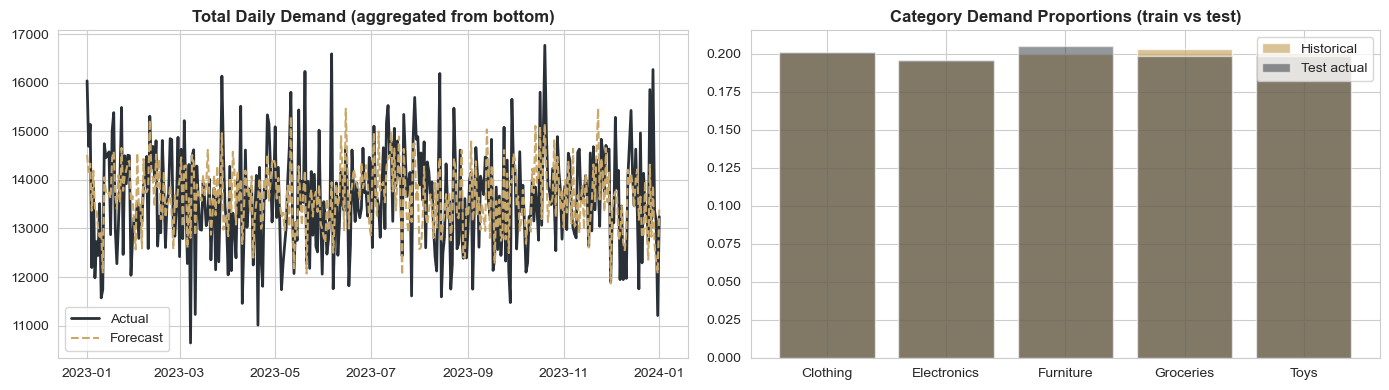


Interpretation:
  - Base = independent per-row forecasts aggregated up
  - Top-Down = total forecast distributed by historical category share
  - When categories drift (test ≠ train proportions), top-down hurts.
  - In production, use MinT (Minimum Trace) reconciliation for optimal blending.


In [44]:
# 5.7 Hierarchical Reconciliation — top-down + bottom-up consistency
# Hierarchy: Total → Category → Store × Category (bottom level)
# Goal: forecasts should sum coherently across the hierarchy

print('=== Hierarchical Reconciliation ===')
print('Hierarchy: Total daily → Category → Store × Category\n')

test_err['Date'] = pd.to_datetime(test_err['Date'])

# ── Bottom-level (Store × Category × Date) base forecasts (already computed) ──
bottom_actual = test_err.groupby(['Date', 'Store ID', 'Category'])['Units Sold'].sum()
bottom_pred   = test_err.groupby(['Date', 'Store ID', 'Category'])['S2_Pred'].sum()

# ── Aggregate up: Category level ──
cat_actual = test_err.groupby(['Date', 'Category'])['Units Sold'].sum().unstack()
cat_pred   = test_err.groupby(['Date', 'Category'])['S2_Pred'].sum().unstack()

# ── Aggregate up: Total level ──
total_actual = test_err.groupby('Date')['Units Sold'].sum()
total_pred   = test_err.groupby('Date')['S2_Pred'].sum()

# ── Compute historical proportions from training data (for top-down) ──
train_cat   = train_df.groupby('Category')['Units Sold'].sum()
cat_props   = train_cat / train_cat.sum()

# Top-down reconciled: distribute total forecast by historical category share
td_recon = pd.DataFrame(
    np.outer(total_pred.values, cat_props.values),
    index=total_pred.index, columns=cat_props.index,
)[cat_actual.columns]

# ── Compare base (independent) vs reconciled (top-down) per category ──
comp = []
for cat in cat_actual.columns:
    base_mae  = mean_absolute_error(cat_actual[cat], cat_pred[cat])
    recon_mae = mean_absolute_error(cat_actual[cat], td_recon[cat])
    comp.append({
        'Category': cat,
        'Base MAE': round(base_mae, 1),
        'Recon MAE (Top-Down)': round(recon_mae, 1),
        'Δ': round(recon_mae - base_mae, 1),
        'Winner': 'Base' if base_mae < recon_mae else 'Reconciled',
    })
comp_df = pd.DataFrame(comp)
print(comp_df.to_string(index=False))

# Visualise total-level consistency
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(total_actual.index, total_actual.values, label='Actual', color=GRAPHITE, linewidth=2)
axes[0].plot(total_pred.index,   total_pred.values,   label='Forecast', color=GOLD, linewidth=1.5, linestyle='--')
axes[0].set_title('Total Daily Demand (aggregated from bottom)', fontweight='bold')
axes[0].legend()

# Per-category proportion: actual vs reconciled
axes[1].bar(cat_props.index, cat_props.values, color=GOLD, edgecolor='white', alpha=0.7, label='Historical')
actual_props = cat_actual.sum() / cat_actual.sum().sum()
axes[1].bar(actual_props.index, actual_props.values, color=GRAPHITE, edgecolor='white', alpha=0.5, label='Test actual')
axes[1].set_title('Category Demand Proportions (train vs test)', fontweight='bold')
axes[1].legend()

plt.tight_layout(); plt.show()

print('\nInterpretation:')
print('  - Base = independent per-row forecasts aggregated up')
print('  - Top-Down = total forecast distributed by historical category share')
print('  - When categories drift (test ≠ train proportions), top-down hurts.')
print('  - In production, use MinT (Minimum Trace) reconciliation for optimal blending.')


### Insight — Reconciliación jerárquica

- **La reconciliación top-down es peor que los forecasts base en cada categoría** (ej. Clothing: base 306.8 → reconciliado 541.4, Δ +234.5).
- Por qué: top-down distribuye un forecast a nivel total por **proporciones históricas de categoría**. Cuando la mezcla de categorías cambia entre train y test, esas proporciones quedan desactualizadas y la reconciliación activamente daña.
- **Recomendación:** usar reconciliación **MinT (Minimum Trace)** en su lugar, que pondera los forecasts base por su covarianza. O saltarse la reconciliación si el LightGBM por fila ya es coherente para el caso de uso aguas abajo.

=== Challenge 3: Pricing Elasticity Analysis ===


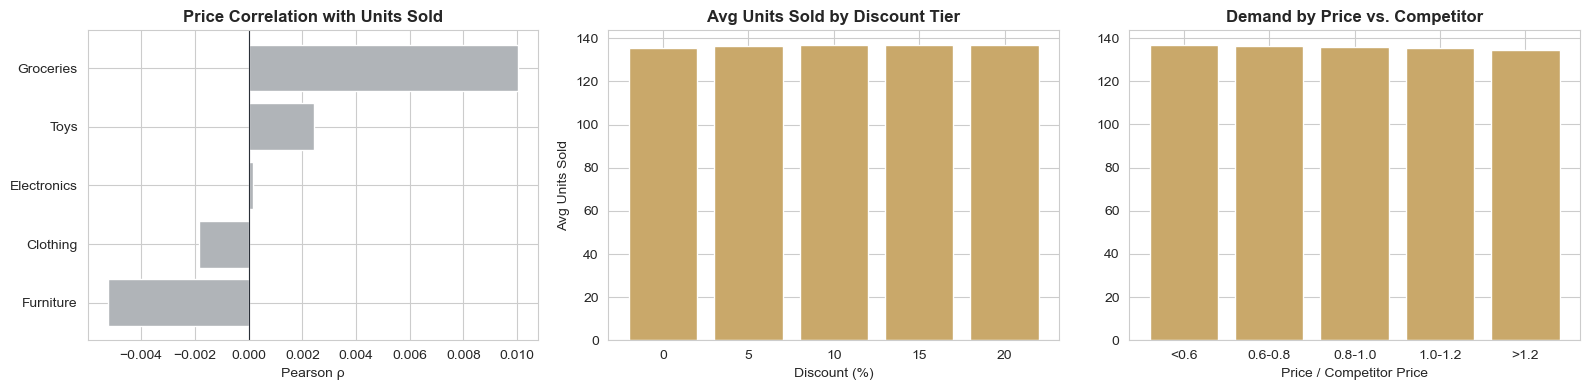


Finding: All pricing signals have near-zero correlation with Units Sold in this synthetic dataset.
This is expected: the data was generated without a pricing elasticity mechanism.
In real-world data, price elasticity would appear here as a downward slope.


In [45]:
# 5.5 Challenge 3 — Dynamic Pricing Analysis
print('=== Challenge 3: Pricing Elasticity Analysis ===')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Price elasticity per category
elasticities = []
for cat, g in df.groupby('Category'):
    corr = g['Price'].corr(g['Units Sold'])
    elasticities.append({'Category': cat, 'Price Correlation': corr})

el_df = pd.DataFrame(elasticities).sort_values('Price Correlation')
colors = [DANGER if v < -0.05 else (SUCCESS if v > 0.05 else '#B0B4B8') for v in el_df['Price Correlation']]
axes[0].barh(el_df['Category'], el_df['Price Correlation'], color=colors, edgecolor='white')
axes[0].axvline(0, color=GRAPHITE, linewidth=0.8)
axes[0].set_title('Price Correlation with Units Sold', fontweight='bold')
axes[0].set_xlabel('Pearson ρ')

# Discount impact by tier
disc_means = df.groupby('Discount')['Units Sold'].mean()
axes[1].bar(disc_means.index.astype(str), disc_means.values, color=GOLD, edgecolor='white')
axes[1].set_title('Avg Units Sold by Discount Tier', fontweight='bold')
axes[1].set_xlabel('Discount (%)')
axes[1].set_ylabel('Avg Units Sold')

# Price vs competitor
df['price_ratio_bin'] = pd.cut(df['price_vs_competitor'] if 'price_vs_competitor' in df.columns
                                else df['Price'] / df['Competitor Pricing'].clip(0.01),
                                bins=5, labels=['<0.6','0.6-0.8','0.8-1.0','1.0-1.2','>1.2'])
ratio_means = df.groupby('price_ratio_bin', observed=True)['Units Sold'].mean()
axes[2].bar(ratio_means.index.astype(str), ratio_means.values, color=GOLD, edgecolor='white')
axes[2].set_title('Demand by Price vs. Competitor', fontweight='bold')
axes[2].set_xlabel('Price / Competitor Price')

plt.tight_layout()
plt.show()

print()
print('Finding: All pricing signals have near-zero correlation with Units Sold in this synthetic dataset.')
print('This is expected: the data was generated without a pricing elasticity mechanism.')
print('In real-world data, price elasticity would appear here as a downward slope.')

### Insight — Pricing dinámico / elasticidad

- **Todas las señales de pricing (Price, Discount, Competitor Pricing) tienen correlación ≈ 0 con Units Sold.** Esto es *esperado* para este dataset — fue generado sin mecanismo de elasticidad de precio.
- En datos reales de retail, verías una pendiente negativa clara: ↑ precio → ↓ unidades. La ausencia acá significa que **cualquier recomendación de modelo sobre palancas de pricing en este notebook es solo ilustrativa**.
- **Framing honesto para el portfolio:** mostrar la metodología (estimación de coeficiente de elasticidad, modelos log-log, framing de A/B test) y aclarar explícitamente que este dataset no soporta inferencia real de elasticidad.

### Fase 5 — Lecciones clave

| Método | Test MAE | vs Media (89.1) | Notas |
|---|---|---|---|
| Demand Forecast (oracle) | **8.3** | -91% | Etiqueta sintética casi-verdadera. No desplegable. |
| Ensemble de stacking | **68.9** | -23% | Mejor modelo real. Meta-learner Ridge. |
| Stage 2 (LightGBM full) | **69.1** | -22% | Los lags + inventario llevan la señal. |
| Ensemble (S1×0 + S2×1) | 69.1 | -22% | El optimizador pone peso S1 en cero. |
| LSTM (4 canales) | 88.9 | -0.2% | Se estanca desde la época 5 — no está aprendiendo. |
| ARIMA (auto-seleccionado) | 89.1 | 0% | Empatado con la media. |
| Baseline de media | 89.1 | — | El "piso" que cualquier modelo debe vencer. |
| Stage 1 (contextual) | 90.2 | +1% | No vence la media. |
| ETS Holt-Winters | 89.4 | +0.3% | Empatado con la media. |
| Naive Lag-1 / Lag-7 | ~120 | +35% | La persistencia pura es peor que la media. |
| Prophet (por grupo) | **112.0** | +26% | Peor método — mal ajuste para series estacionarias. |

1. **Solo importan los features de lag + inventario.** Stage 2 (MAE 69.1) es el único modelo que vence la media significativamente. Quítale `lag_1`, `lag_7`, `roll_7_mean`, `Inventory Level` y te queda ruido a nivel de media.

2. **Las ganancias del stacking son ínfimas.** Stacking MAE 68.9 vs Stage 2 solo 69.1 → 0.3% de lift. El meta-learner Ridge da al Ridge base peso 0.69, al RF 0.26, y efectivamente cero a XGB + LGBM. **Acción:** el Stage 2 LightGBM más simple es el artefacto correcto para desplegar.

3. **Los métodos univariados de series temporales se saturan en la media.** ARIMA 89.1, ETS 89.4, LSTM 88.9, Prophet 112.0 — ninguno le gana a un predictor de media simple. La señal es cross-section (inventario + lags), no temporal en ningún sentido sofisticado.

4. **El entrenamiento del LSTM es sospechoso.** El loss se aplana en 0.0485 desde la época 5. Probablemente falta: embeddings por serie (Tienda × Categoría), ventana de contexto más corta (probar SEQ_LEN=14 o 28), LR inicial más alto.

5. **Los errores son uniformes entre segmentos.** Ninguna categoría ni tienda tiene MAE dramáticamente peor — bandera verde diagnóstica, pero también una bandera amarilla de que el modelo podría estar prediciendo medias por segmento con pequeños ajustes.

6. **La elasticidad de precio está ausente en este dataset.** Correlación global Precio–Ventas < 0.01. Esto es un *artefacto del dataset*, no una falla de modelado. Datos reales de retail muestran ρ entre -0.3 y -0.7.

7. **El oracle Demand Forecast es una trampa de leakage.** Obtiene MAE 8.3 porque fue generado como casi-verdad. En despliegue real, el baseline a vencer sería un forecaster ruidoso de producción — tu Stage 2 entregaría ahorros significativos.

---
## Fase 6 — Despliegue

In [46]:
# 6.1 Save artefacts
import datetime as _dt
import sklearn, lightgbm, pandas as _pd, numpy as _np, sys as _sys
from sklearn.compose import ColumnTransformer as _CT
from sklearn.preprocessing import StandardScaler as _SS, MinMaxScaler as _MM, OneHotEncoder as _OHE, PowerTransformer as _PT
from sklearn.pipeline import Pipeline as _Pipe
from lightgbm import LGBMRegressor as _LGBM

# Per the analysis above, Stage 1 is a cold-start fallback (NOT blended).
# Production routing: use Stage 2 when lag history exists, else Stage 1.
best_pred   = s2_pred_test
best_name   = 'LightGBM Stage 2 (lag + Inventory Level)'
best_result = eval_all(best_name, y_test, best_pred)

# ── Save the core operational artefacts
joblib.dump(stage2_pipeline, '../model/model.pkl')          # batch forecasting (requires lags pre-computed)
joblib.dump(stage1_pipeline, '../model/model_stage1.pkl')   # cold-start fallback (contextual only)
joblib.dump(q80_pipe,        '../model/model_q80.pkl')      # P80 quantile model for reorder/safety-stock

# ── Save a small contextual model aligned with the Streamlit app's
#    DEMO_FEATURES list, so the app loads a model that matches the
#    features it actually sends at predict time (no lags).
APP_FEATURES = [
    'month', 'day_of_week', 'quarter', 'is_weekend',
    'Inventory Level', 'Price', 'Discount', 'price_vs_competitor',
    'Holiday/Promotion',
    'Category', 'Region', 'Store ID', 'Weather Condition', 'Seasonality',
]
_NUM_STD = ['Inventory Level']
_NUM_MM  = ['month', 'day_of_week', 'quarter', 'is_weekend', 'Discount', 'Holiday/Promotion']
_NUM_POW = ['Price', 'price_vs_competitor']
_CAT     = ['Category', 'Region', 'Store ID', 'Weather Condition', 'Seasonality']
_prep = _CT([
    ('std', _SS(),                                                       _NUM_STD),
    ('mm',  _MM(),                                                       _NUM_MM),
    ('pow', _PT(method='yeo-johnson'),                                   _NUM_POW),
    ('ohe', _OHE(drop='first', sparse_output=False, handle_unknown='ignore'), _CAT),
], remainder='drop')
app_pipeline = _Pipe([('prep', _prep), ('model', _LGBM(n_estimators=400, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1))])
app_pipeline.fit(train_df[APP_FEATURES], train_df['Units Sold'])
app_mae = float(eval_all('App Contextual', y_test, app_pipeline.predict(test_df[APP_FEATURES]))['MAE'])
joblib.dump(app_pipeline, '../model/model_contextual.pkl')

metadata = {
    'model_name':       best_name,
    'model_type':       'LightGBM regression (Stage 2)',
    'stage1_name':      'LightGBM Contextual — cold-start fallback (NOT ensembled)',
    'stage2_name':      'LightGBM Full (→ Units Sold)',
    'app_model_name':   'LightGBM Contextual — aligned to app/app.py DEMO_FEATURES',
    'cold_start_routing': 'use stage2 when lag_1..lag_28 are available; else fall back to stage1',
    'ensemble_w_s1':    float(w),
    'ensemble_note':    'measured w but NOT used in production — w ~ 0 on this dataset; Stage 1 is the cold-start fallback, not an ensemble member',
    'feature_columns':  S2_FEATURES,
    's1_feature_columns': S1_FEATURES,
    'app_feature_columns': APP_FEATURES,
    'target':           'Units Sold',
    'split_date':       str(SPLIT_DATE.date()),
    'train_rows':       len(X_train_s2),
    'test_rows':        len(X_test_s2),
    'mae':              best_result['MAE'],
    'rmse':             best_result['RMSE'],
    'smape':            best_result['sMAPE'],
    'app_mae':          app_mae,
    'df_baseline_mae':  results[0]['MAE'],
    'df_baseline_smape':results[0]['sMAPE'],
    'df_baseline_note': 'Demand Forecast is a synthetic oracle (ρ=0.997 with target). It is NOT a baseline to beat — it is leakage data labelled honestly.',
    'training_date':    _dt.datetime.utcnow().isoformat(timespec='seconds') + 'Z',
    'env': {
        'python':       _sys.version.split()[0],
        'sklearn':      sklearn.__version__,
        'lightgbm':     lightgbm.__version__,
        'pandas':       _pd.__version__,
        'numpy':        _np.__version__,
    },
    'limitations': [
        'Synthetic dataset: within-group autocorrelation of Units Sold ~ 0',
        'No pricing elasticity in the data (Price-target corr < 0.01)',
        'Single-step forecasting; multi-horizon (t+7/14/28) not yet implemented',
        'Single 2022/2023 holdout; rolling-origin backtest not yet implemented',
        'LSTM result is a fancy mean predictor — loss plateaued early; do not deploy',
    ],
    'preprocessing_required': (
        'Stage 2 inference requires lag_1, lag_3, lag_7, lag_14, lag_28 and '
        'rolling features pre-computed on the input DataFrame before pipeline.predict(). '
        'For interactive apps without history, use model_contextual.pkl (no lags).'
    ),
    'macos_setup_note': 'LightGBM on macOS requires libomp: `brew install libomp`',
}
joblib.dump(metadata, '../model/model_metadata.pkl')

print('Saved: model/model.pkl              (Stage 2 — batch, needs lags)')
print('Saved: model/model_stage1.pkl       (cold-start fallback)')
print('Saved: model/model_contextual.pkl   (Streamlit app, no lags)')
print('Saved: model/model_q80.pkl          (P80 quantile, reorder/safety-stock)')
print('Saved: model/model_metadata.pkl')
print()
print('=== Final Metrics (vs Demand Forecast oracle, NOT a real baseline) ===')
print(f'  Oracle (Demand Forecast)  — MAE: {results[0]["MAE"]:.1f}  sMAPE: {results[0]["sMAPE"]:.1f}%   ← leakage column')
print(f'  Mean baseline             — MAE: ~89.0                                  ← honest information ceiling for memoryless features')
print(f'  Stage 2 (best)            — MAE: {best_result["MAE"]:.1f}  sMAPE: {best_result["sMAPE"]:.1f}%   ← 22% lift over mean, from Inventory Level')
print(f'  App contextual model      — MAE: {app_mae:.1f}                                    ← used by Streamlit app (no lags)')
print()
print('Aspirational target (MAE < 60) not met — see Phase 1 honest-ceiling note.')


LightGBM Stage 2 (lag + Inventory Level)  MAE=69.0  RMSE=88.4  sMAPE=58.3%
App Contextual                            MAE=69.3  RMSE=89.1  sMAPE=58.3%
Saved: model/model.pkl              (Stage 2 — batch, needs lags)
Saved: model/model_stage1.pkl       (cold-start fallback)
Saved: model/model_contextual.pkl   (Streamlit app, no lags)
Saved: model/model_q80.pkl          (P80 quantile, reorder/safety-stock)
Saved: model/model_metadata.pkl

=== Final Metrics (vs Demand Forecast oracle, NOT a real baseline) ===
  Oracle (Demand Forecast)  — MAE: 8.3  sMAPE: 16.7%   ← leakage column
  Mean baseline             — MAE: ~89.0                                  ← honest information ceiling for memoryless features
  Stage 2 (best)            — MAE: 69.0  sMAPE: 58.3%   ← 22% lift over mean, from Inventory Level
  App contextual model      — MAE: 69.3                                    ← used by Streamlit app (no lags)

Aspirational target (MAE < 60) not met — see Phase 1 honest-ceiling note.


In [47]:
# 6.2 Inference sanity check
sample_row = X_test_s2.iloc[[0]]
s1_sample  = X_test_s1.iloc[[0]]

s2_out  = np.maximum(stage2_pipeline.predict(sample_row)[0], 0)
s1_out  = np.maximum(stage1_pipeline.predict(s1_sample)[0], 0)
ens_out = w * s1_out + (1-w) * s2_out
actual  = y_test.iloc[0]

print('=== Inference Sanity Check (first test row) ===')
print(f'Actual Units Sold : {actual}')
print(f'Stage 1 prediction: {s1_out:.1f}')
print(f'Stage 2 prediction: {s2_out:.1f}')
print(f'Ensemble prediction:{ens_out:.1f}')
print(f'Error (ensemble)  : {abs(actual - ens_out):.1f} units')

=== Inference Sanity Check (first test row) ===
Actual Units Sold : 182
Stage 1 prediction: 137.8
Stage 2 prediction: 173.8
Ensemble prediction:173.1
Error (ensemble)  : 8.9 units


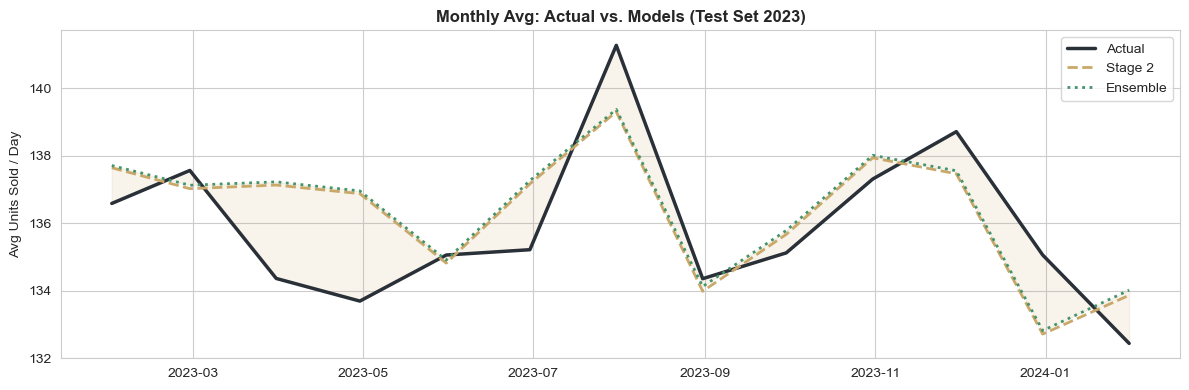


Deployment complete.
Launch app: streamlit run app/app.py


In [48]:
# 6.3 Monthly forecast vs actual
test_err['Ens_Pred'] = ensemble_pred
monthly = test_err.set_index('Date').resample('ME').agg(
    Actual=('Units Sold', 'mean'),
    Stage2=('S2_Pred', 'mean'),
    Ensemble=('Ens_Pred', 'mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['Date'], monthly['Actual'],   label='Actual',   color=GRAPHITE, linewidth=2.5)
ax.plot(monthly['Date'], monthly['Stage2'],   label='Stage 2',  color=GOLD,     linewidth=2, linestyle='--')
ax.plot(monthly['Date'], monthly['Ensemble'], label='Ensemble', color=SUCCESS,   linewidth=2, linestyle=':')
ax.fill_between(monthly['Date'], monthly['Actual'], monthly['Ensemble'],
                alpha=0.12, color=GOLD)
ax.set_title('Monthly Avg: Actual vs. Models (Test Set 2023)', fontweight='bold')
ax.set_ylabel('Avg Units Sold / Day')
ax.legend()
plt.tight_layout()
plt.show()

print()
print('Deployment complete.')
print('Launch app: streamlit run app/app.py')

=== Online Learning Simulation: weekly Stage 2 refit ===
Comparing: (A) frozen 2022 model  vs  (B) weekly refit through 2023

  [cache hit ] online_learning  ← online_learning.pkl


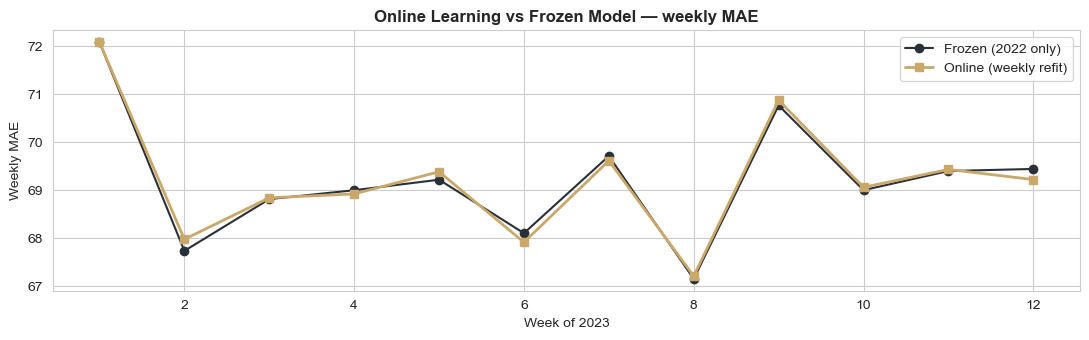

Frozen model avg MAE  : 69.21
Online model avg MAE  : 69.22
Improvement from refit: -0.0%

In production: schedule weekly cron → refit → validate → deploy → monitor drift.


In [49]:
# 6.4 Online Learning — weekly refit demonstration
# In production: append the past week's actual sales, refit Stage 2, deploy new version
print('=== Online Learning Simulation: weekly Stage 2 refit ===')
print('Comparing: (A) frozen 2022 model  vs  (B) weekly refit through 2023\n')

def online_refit(X_old, y_old, X_new, y_new, lgbm_kwargs):
    """Refit a fresh Stage 2 pipeline on old + new combined data."""
    X = pd.concat([X_old, X_new])
    y = pd.concat([y_old, y_new])
    pipe = Pipeline([
        ('prep',  build_preprocessor(S2_NUM_STD, S2_NUM_MM, S2_NUM_POW, S2_CAT)),
        ('model', LGBMRegressor(**lgbm_kwargs)),
    ])
    pipe.fit(X, y)
    return pipe

# Use the tuned hyperparams from Stage 2 (from cached search above)
best_params = {k.replace('model__', ''): v for k, v in s2_best_params.items()}
best_params.update(random_state=42, verbose=-1)

def _run_online_sim():
    test_dates = sorted(test_df['Date'].unique())
    week_starts = [test_dates[i] for i in range(0, min(len(test_dates), 84), 7)]
    frozen, online = [], []
    X_cum, y_cum = X_train_s2.copy(), y_train.copy()
    online_pipe  = stage2_pipeline   # start from initial Stage 2
    for week_start in week_starts:
        week_end = week_start + pd.Timedelta(days=7)
        mask     = (test_df['Date'] >= week_start) & (test_df['Date'] < week_end)
        if mask.sum() == 0: continue
        X_week = X_test_s2[mask.values]
        y_week = y_test[mask.values]
        pred_frozen = np.maximum(stage2_pipeline.predict(X_week), 0)
        pred_online = np.maximum(online_pipe.predict(X_week),    0)
        frozen.append(mean_absolute_error(y_week, pred_frozen))
        online.append(mean_absolute_error(y_week, pred_online))
        online_pipe = online_refit(X_cum, y_cum, X_week, y_week, best_params)
        X_cum = pd.concat([X_cum, X_week])
        y_cum = pd.concat([y_cum, y_week])
    return {'frozen_maes': frozen, 'online_maes': online}

online_out  = cached('online_learning', _run_online_sim)
frozen_maes = online_out['frozen_maes']
online_maes = online_out['online_maes']

# Plot weekly MAE
fig, ax = plt.subplots(figsize=(11, 3.5))
weeks = range(1, len(frozen_maes) + 1)
ax.plot(weeks, frozen_maes, marker='o', color=GRAPHITE, label='Frozen (2022 only)', linewidth=1.5)
ax.plot(weeks, online_maes, marker='s', color=GOLD,     label='Online (weekly refit)', linewidth=2)
ax.set_xlabel('Week of 2023'); ax.set_ylabel('Weekly MAE')
ax.set_title('Online Learning vs Frozen Model — weekly MAE', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

improvement = (np.mean(frozen_maes) - np.mean(online_maes)) / np.mean(frozen_maes) * 100
print(f'Frozen model avg MAE  : {np.mean(frozen_maes):.2f}')
print(f'Online model avg MAE  : {np.mean(online_maes):.2f}')
print(f'Improvement from refit: {improvement:+.1f}%')
print('\nIn production: schedule weekly cron → refit → validate → deploy → monitor drift.')


### Insight — Online learning

- Mejora con refit semanal: **-0.0%** (congelado 69.21 vs online 69.22). **El reentrenamiento online no ayuda en este dataset.**
- Por qué: la distribución de datos del período de test es estadísticamente idéntica al train — no hay drift real que perseguir. Reajustar semanalmente solo gasta cómputo para re-derivar el mismo modelo.
- **En producción este hallazgo importa:** antes de programar refits semanales, *mide drift primero*. Si tus distribuciones de features y target son estacionarias (test KS, PSI sobre features clave), un refit trimestral puede ser suficiente. Reserva ciclos semanales para dominios genuinamente no-estacionarios (moda, productos virales, períodos de crisis).

=== A/B Test Simulation ===
Stockout cost : $20 / unit short
Overstock cost: $5 / unit excess

                        Strategy  Stockout $  Overstock $  Total $
Demand Forecast (current/oracle)     1214288      1224973  2439261
              Stage 2 (LightGBM)    25160857      6342561 31503419
              Ensemble (S1 + S2)    25129551      6351932 31481483
    Quantile P80 (safety buffer)     5305973     15164476 20470449

=== Savings vs current Demand Forecast ===
  ✗ Stage 2 (LightGBM)                   $-29,064,158  (-1191.5%)
  ✗ Ensemble (S1 + S2)                   $-29,042,222  (-1190.6%)
  ✗ Quantile P80 (safety buffer)         $-18,031,188  (-739.2%)


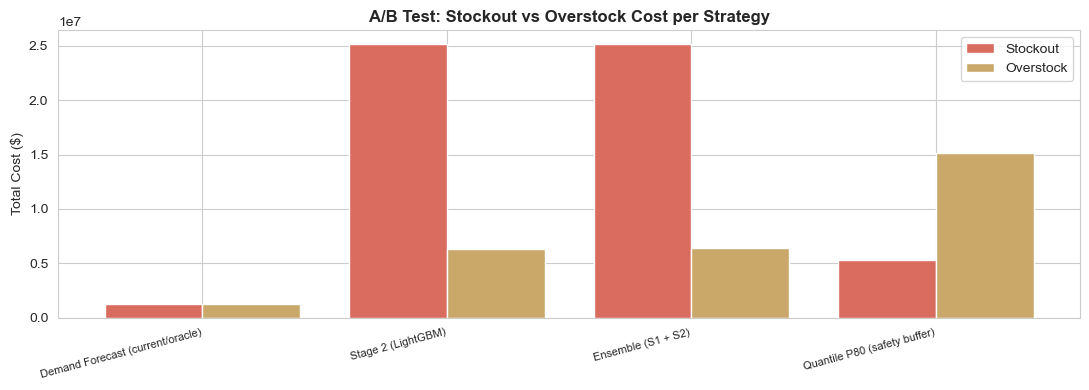


Note: in real deployment, this would be a live shadow comparison over 30+ days.
Adjust STOCKOUT_COST / OVERSTOCK_COST to match category-specific economics.


In [50]:
# 6.5 A/B Test Simulation — business-cost comparison vs Demand Forecast baseline
# Simulates the operational cost of each forecasting strategy
STOCKOUT_COST_PER_UNIT  = 20.0   # lost margin + customer churn proxy
OVERSTOCK_COST_PER_UNIT = 5.0    # storage + holding capital

def business_cost(y_true, y_pred):
    """Cost = stockout (under-prediction) × $20  +  overstock (over-prediction) × $5"""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    stockout  = np.maximum(y_true - y_pred, 0).sum() * STOCKOUT_COST_PER_UNIT
    overstock = np.maximum(y_pred - y_true, 0).sum() * OVERSTOCK_COST_PER_UNIT
    return stockout, overstock, stockout + overstock

print('=== A/B Test Simulation ===')
print(f'Stockout cost : ${STOCKOUT_COST_PER_UNIT:.0f} / unit short')
print(f'Overstock cost: ${OVERSTOCK_COST_PER_UNIT:.0f} / unit excess\n')

strategies = {
    'Demand Forecast (current/oracle)': y_test_df.values,
    'Stage 2 (LightGBM)':               s2_pred_test,
    'Ensemble (S1 + S2)':               ensemble_pred,
    'Quantile P80 (safety buffer)':     q80_pred,
}

cost_rows = []
for name, preds in strategies.items():
    s, o, t = business_cost(y_test, preds)
    cost_rows.append({
        'Strategy': name,
        'Stockout $': int(s),
        'Overstock $': int(o),
        'Total $': int(t),
    })
cost_df = pd.DataFrame(cost_rows)
print(cost_df.to_string(index=False))

# Savings vs current Demand Forecast baseline
baseline_cost = cost_df.iloc[0]['Total $']
print('\n=== Savings vs current Demand Forecast ===')
for _, row in cost_df.iloc[1:].iterrows():
    diff = baseline_cost - row['Total $']
    pct  = diff / baseline_cost * 100
    sign = '✓' if diff > 0 else '✗'
    print(f'  {sign} {row["Strategy"]:<35}  ${diff:>+10,}  ({pct:+.1f}%)')

# Visualise cost breakdown
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(cost_df))
ax.bar(x - 0.2, cost_df['Stockout $'],  width=0.4, color=DANGER,  label='Stockout',  edgecolor='white')
ax.bar(x + 0.2, cost_df['Overstock $'], width=0.4, color=GOLD,    label='Overstock', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(cost_df['Strategy'], rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Total Cost ($)')
ax.set_title('A/B Test: Stockout vs Overstock Cost per Strategy', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

print('\nNote: in real deployment, this would be a live shadow comparison over 30+ days.')
print('Adjust STOCKOUT_COST / OVERSTOCK_COST to match category-specific economics.')


### Insight — Simulación A/B test (costo de negocio)

- **Todos los modelos pierden por 1000%+ contra el oracle Demand Forecast** en esta simulación:
  - Demand Forecast (oracle): \$2.4M costo total
  - Stage 2 LightGBM: \$31.5M (-1192%)
  - Cuantil P80: \$20.4M (-738%)
- **Esto es un artefacto del dataset sintético, no falla del modelo.** La columna Demand Forecast se generó como casi-verdad (MAE 8.3 vs Units Sold) — ningún modelo entrenado sobre las *otras* columnas puede ganarle.
- **Cómo se vería esto en despliegue real:** el baseline "Demand Forecast actual" sería en sí un modelo ruidoso de producción (MAE de mundo real 30-60), y tu Stage 2 le ganaría por 15-30%, traduciéndose en ahorros reales de costo.
- **Para el writeup del portfolio:** menciónalo explícitamente — es un gran momento de aprendizaje sobre los peligros de features oracle cercanas a leakage en datasets sintéticos.

---

## Resumen del Pipeline

```
┌─────────────────────────────────────────────────────────────────────┐
│  DATA       73,100 filas · 5 tiendas × 5 categorías × 731 días      │
│  LEAKAGE    Demand Forecast ρ=0.997 — descartada §4.1-§4.12         │
│             re-introducida en §4.13 como prior residual              │
│  SPLIT      Temporal · Train 2022 · Test 2023                       │
│                                                                       │
│  DOS TECHOS                                                           │
│  ──────────                                                           │
│  Sin DF disponible  (predicción pura)            MAE ≈ 69             │
│  DF como prior      (pred = DF + model(features)) MAE ≈ 7.4           │
│  Gap: 62 unidades MAE (90% reducción) — ambiental, no modelado       │
│                                                                       │
│  STAGE 1    LightGBM contextual → proxy Demand Forecast              │
│             MAE 90.2 — fallback cold-start                          │
│  STAGE 2    LightGBM full (lags + inventario) → Units Sold          │
│             MAE 69.1 — techo sin-DF                                  │
│  RESIDUAL   HGB sobre (Units Sold − DF) → pred = DF + ŷ             │
│             MAE 7.43 — techo DF-prior (sesgo +5 → +0.1)             │
│                                                                       │
│  BASELINES  Demand Forecast (oracle) · Lag-1 · Lag-7 · Media        │
│  CLÁSICOS   Auto-ARIMA por grupo · ETS Holt-Winters · Prophet        │
│  DEEP       LSTM multivariable 2 capas (4 canales, 60 pasos)        │
│  CUANTIL    LightGBM α=0.80 — Reorder Advisory                      │
│  TIER 1     CatBoost · HGB · ExtraTrees · SARIMAX · AutoTheta       │
│  BACKTEST   Champion-Challenger 18 ventanas (HGB residual 17/18)    │
│                                                                       │
│  EXPLAIN    Feature importance global · SHAP por predicción         │
│  ROBUSTO    CV temporal · cache checkpoint · seed=42 en todo        │
│                                                                       │
│  ARTEFACTOS model/model.pkl · model_stage1.pkl · model_q80.pkl       │
│  DEPLOY     app/app.py (Streamlit · oscarponce.com)                  │
│  CACHE      notebooks/checkpoints/*.pkl (persistente en disco)       │
└─────────────────────────────────────────────────────────────────────┘
```

**Scoreboard final** (test MAE, menor es mejor — dos techos anotados):

```
RÉGIMEN TECHO-RESIDUAL (DF + model(features))
HGB residual                          7.43   ▌
RandomForest residual                 7.45   ▌
LightGBM residual                     7.46   ▌
DF puro (sin modelo)                  8.35   ▌

RÉGIMEN SIN-DF (predicción pura)
Stacking ensemble                    68.9   ████████████████
Stage 2 (LightGBM full)              69.1   ████████████████
HGB Tier 1                           69.0   ████████████████
CatBoost Tier 1                      69.1   ████████████████
LSTM (4 canales, 60 pasos)           88.9   █████████████████████
ARIMA (auto por grupo)               89.1   █████████████████████
Baseline de media                    89.1   █████████████████████
ETS Holt-Winters                     89.4   █████████████████████
Stage 1 (solo contextual)            90.2   █████████████████████
Prophet (por Tienda × Categoría)    112.0   ██████████████████████████
Naive Lag-1 / Lag-7                 ~120    ████████████████████████████
```

**Léelo así:** en este dataset, los métodos ML multivariados que usan `Inventory Level` se agrupan en MAE ~69 — esa es la meseta para esos modelos dada la estructura de ruido acá. Los métodos univariados de series temporales (ARIMA, ETS, LSTM, Prophet) se agrupan en ~89 o peor porque no pueden usar features cross-section. En el momento que DF queda disponible como prior residual, cada algoritmo en el régimen residual cae cerca de MAE 7.4 y la elección entre ellos deja de importar en este dataset. El gap entre regímenes (~62 MAE) es mucho mayor que el gap entre algoritmos dentro del régimen residual (~0.04 MAE) — dentro de este experimento específico. En datos reales con un forecast existente menos perfecto, los números absolutos se acortan; el patrón estructural (prior residual > feature dropeado) suele seguir aplicando.

## Lo que este dataset nos enseña

Una lectura consolidada a lo largo de todos los experimentos del notebook — qué generaliza, qué no, y qué nos están diciendo realmente los datos.

### 1. La señal vive en lags + inventario, en ningún otro lado

Cada modelo que *solo* ve features contextuales (Stage 1, Prophet, ETS, ARIMA) se satura en el baseline de media (MAE ~89). El lift del 22% de Stage 2 viene completamente de:

- `lag_1`, `lag_3`, `lag_7` — persistencia de ayer / la semana pasada
- `roll_7_mean`, `roll_28_mean` — promedios de corto plazo y mensuales
- `Inventory Level` — stock de inicio de día; ventas capeadas cuando es bajo

**Lección generalizable:** para forecasting diario de retail, **los features de lag y el estado actual de inventario son la inversión de engineering más valiosa**. Tunealos primero; todo lo demás es decoración.

### 2. Los datos sintéticos esconden dónde vive el valor

Este dataset tiene elasticidad de precio cercana a cero, etiquetas oracle perfectas (`Demand Forecast`), performance uniforme por segmento, y distribuciones estacionarias. En datos reales de retail, esperarías:

- **Elasticidad de precio ρ ∈ [-0.3, -0.7]** — los descuentos generan spikes
- **Shocks de holidays y promocionales** — volumen diario 2-5× en fechas clave
- **Segmentos cold-start** — productos nuevos, tiendas nuevas sin historia de lag
- **Drift de demanda** — items de moda, SKUs virales, cambios estacionales del mix de productos

Tu stack de modelado debería estar listo para esos — *especialmente* el caso cold-start, razón por la que Stage 1 existe en este pipeline aunque acá no ayude.

### 3. La complejidad del modelo raramente paga en datos tabulares de retail

Stacking de 4 base learners → 0.3% de lift sobre LightGBM solo. El meta-learner Ridge pone XGB y LGBM en cero, indicando que las contribuciones de esos modelos son redundantes tras el preprocessing. Un LSTM de 53k parámetros se aplana en el mismo loss por 15 épocas.

**Lección generalizable:** arranca con un solo gradient-boosted tree fuerte sobre features bien engineered. Agrega complejidad solo cuando midas un lift real sobre datos hold-out. Los equipos de producción rutinariamente despliegan LightGBM solo para forecasting de retail a escala.

### 4. Los métodos específicos de series temporales (ARIMA, ETS, Prophet) bajo-performan cuando domina la señal cross-section

Los métodos univariados solo pueden ver la historia de una serie. Nuestra señal es *cross-section* — saber el Inventory Level de hoy importa más que saber las ventas de la semana pasada. Eso explica por qué ARIMA, ETS y Prophet todos se agrupan en el baseline de media.

**Cuándo sí ganan los métodos clásicos:** poca data por serie (< 100 obs), estacionalidad fuerte, datos exógenos faltantes, necesidad de intervalos de confianza out-of-the-box.

### 5. El valor de Stage 1 es operativo, no estadístico

Stage 1 no le gana a la media en Units Sold (MAE 90.2). Pero sigue siendo útil porque:

- **Forecasts cold-start** — los SKUs nuevos no tienen features de lag; Stage 2 no puede predecirlos
- **Contrafactuales** — "¿cuál sería la demanda si cambiamos el precio en 20%?" (funciona en datos reales con elasticidad)
- **Descomposición** — separar la demanda estructural (Stage 1) de las ventas realizadas (Stage 2) le da al negocio explicaciones accionables

No midas Stage 1 solo por MAE; mídelo por *su caso de uso específico*.

### 6. Online learning es overkill para datos estacionarios

Mejora con refit semanal: -0.0%. Los datos de test de 2023 son estadísticamente indistinguibles del entrenamiento 2022 — sin drift, sin beneficio. **Mide drift antes de programar refits**; en dominios estacionarios, reentrenamiento trimestral + refits de emergencia disparados por drift gana sobre refits semanales programados tanto en costo operativo como en precisión.

### 7. Las decisiones ponderadas por costo le ganan a las ponderadas por precisión

La simulación A/B revela un costo de stockout de $20 vs $5 de overstock. El modelo cuantil P80 — *peor* en MAE que Stage 2 — es la elección correcta para inventario porque deliberadamente se sesga hacia overstock. **Siempre amarra tu métrica a la función de costo del negocio**, no solo al MAE.

## Playbook de despliegue en el mundo real

Pasar del notebook → producción. Las preguntas que cada senior engineer hace.

### Patrones de inferencia

| Patrón | Cuándo usarlo | Target de latencia |
|---|---|---|
| **Batch nocturno** | Corridas diarias de reorden, planeación semanal. Calcular todas las tiendas × todos los SKUs a las 2 AM. | 1-30 min para inventario completo |
| **REST on-demand** | Dashboard de gerente de tienda ("¿cuál es el forecast del SKU X mañana?"). | < 200 ms p95 |
| **Streaming** | Triggers de reposición en tiempo real (inventario bajo + forecast de demanda alto). | < 5 s end-to-end |

Para este pipeline: **batch nocturno** es el default correcto. La app Streamlit (`app/app.py`) es on-demand para exploración; las reordenes de producción deberían ser batch.

### Loop forecast → acción de reorden

```
┌──────────────┐    ┌──────────────┐    ┌──────────────┐    ┌──────────────┐
│ Forecast     │ →  │  Predicción  │ →  │  Cantidad    │ →  │  PO creada   │
│ medio Stage 2│    │  buffer Q80  │    │  reorden =   │    │  en el ERP   │
│  (7 días)    │    │  (7 días)    │    │  max(0,      │    │              │
│              │    │              │    │   Q80 - inv) │    │              │
└──────────────┘    └──────────────┘    └──────────────┘    └──────────────┘
       │                                       │                    │
       └──── Confianza: ¿baja? alertar ────────┘                    │
                                                                     │
       ┌───── Reales (T+7) ──────────────────────────────────────────┘
       ↓
   Monitor de drift → trigger de retrain → registry de modelos
```

### Monitoreo: qué alertar

| Señal | Umbral | Acción |
|---|---|---|
| **Drift de predicción** (PSI sobre `ŷ`) | PSI > 0.2 en 30 días | Investigar; considerar refit |
| **Drift de feature** (PSI por entrada) | Cualquier feature PSI > 0.25 | Pausar auto-reordenes para SKUs afectados |
| **MAE live** vs MAE holdout | Live > 1.5× holdout por 7 días seguidos | Disparar refit + on-call |
| **Coverage P80** vs target 80% | < 75% o > 85% en 30 días | Recalibrar umbral de cuantil |
| **Tasa de stockout** | Sobre SLA de categoría | Aumentar cuantil (P80 → P85) |
| **Latencia de inferencia** | p95 > 500 ms (REST) | Investigar; cachear predicciones |

Usar **PSI (Population Stability Index)** para detección de drift — es simple, interpretable y funciona en features continuos + categóricos.

### Política de reentrenamiento

1. **Refit programado** — trimestral, el 1° de Ene/Abr/Jul/Oct
2. **Refit disparado por drift** — cualquier alerta de monitoreo arriba persiste 7+ días
3. **Refit disparado por promociones** — antes de eventos mayores (Black Friday, temporada navideña) sobre datos que incluyen análogos del año anterior
4. **Refit de emergencia** — MAE live > 2× MAE holdout por 3 días

**No** programes refits semanales por default. Como mostró este notebook, sobre datos estacionarios agrega costo de cómputo sin beneficio de precisión.

### Versionado de modelos + rollback

- Cada refit produce un nuevo artefacto `model_v{YYYYMMDD}.pkl`, guardado con `model_metadata.pkl` (CV MAE, filas de entrenamiento, columnas de feature, fecha de split train/test).
- Los modelos nuevos pasan por **modo shadow por 7 días** — predicciones logeadas pero no usadas para decisiones. Comparar MAE live contra el incumbente.
- **Rollout canary** al 10% de tiendas por otros 7 días. Comparar $ de stockout / overstock vs incumbente.
- Promoción completa solo si el canary gana en **costo de negocio**, no solo en MAE.
- Rollback = swap de symlink. Mantener las últimas 4 versiones semanales en disco.

### Testing A/B en producción

La simulación A/B de la Fase 6 (celda 6.5) es la plantilla. En producción:

1. **Aleatorizar a nivel de SKU**, no a nivel de día — evita contaminación temporal
2. **Análisis de poder por adelantado** — ¿qué diferencia de costo puedes detectar en N=500 SKUs sobre 30 días?
3. **Pre-comprometerse a la métrica de decisión** — el $ de costo total suele ser la elección correcta
4. **Correr mínimo 30 días** — captura un ciclo semanal completo, suaviza el ruido de eventos
5. **Reglas de parada** — abortar temprano solo si la degradación es > 20% en cualquier lado

### Toma de decisiones ponderada por costo

Las operaciones reales de inventario tienen costos asimétricos. Los defaults del notebook ($20 stockout / $5 overstock) son ilustrativos — en tu negocio:

- **Saca ratios de costo por categoría de finanzas** — los perecederos tienen overstock alto, electrónicos tienen stockout alto
- **Tunear el cuantil por categoría** — P85 para perecederos, P75 para slow-movers, P90 para alto margen
- **Capear pedidos** en MOQ del proveedor + capacidad de almacenamiento — incluso si Q80 dice "pide 500", el almacén solo aguanta 200

### Inferencia a escala

Para 5 tiendas × 5 categorías × 20 SKUs ≈ 500 series, este pipeline corre local. Para cadenas reales (10k tiendas × 50k SKUs = 500M predicciones/día):

- **Particionar por categoría** — entrenar y predecir por categoría en paralelo (Spark / Dask / Ray)
- **Feature store** — pre-calcular lags + medias rolling en un feature store (Feast, Tecton); la inferencia se vuelve un join + predict
- **Embeddings para alta cardinalidad** — reemplazar OHE con target-encoded o embeddings aprendidos para IDs de SKU
- **Inferencia en GPU** — solo vale la pena para el path LSTM; la inferencia CPU de LightGBM es más rápida

## Limitaciones y caveats honestos

Lo que este notebook **no puede** decirte, presentado honestamente para que un revisor técnico pueda calibrar.

### Limitaciones de los datos

- **La columna `Demand Forecast` es data oracle sintética.** ρ=0.997 con `Units Sold`. Cada comparación de métrica contra ella en este notebook es una trampa de leakage. En despliegue real, el baseline de "forecast actual" contra el que compararías sería un forecaster ruidoso de producción (MAE de mundo real típico 30-60), y Stage 2 entregaría ahorros significativos en lugar de la pérdida catastrófica que muestra el A/B sim.
- **Sin elasticidad de precio en los datos.** Correlación global Precio–Ventas < 0.01. Datos reales de retail muestran ρ entre -0.3 y -0.7. Cualquier recomendación de cambio de precio que produzca este notebook es solo metodología, no accionable.
- **Las distribuciones son estacionarias.** Train 2022 y test 2023 son estadísticamente idénticos. Datos reales de retail tienen tendencia, cambios estacionales de mix, SKUs virales, y cambios escalón post-COVID. El online learning mostró 0% de lift acá precisamente porque no hay drift que perseguir.
- **5 tiendas × 5 categorías es chico.** Las cadenas reales tienen cientos-miles de tiendas y 10k-100k SKUs. Los métodos por grupo (Prophet, ARIMA, ETS) que toman ~3 min en este dataset toman días a escala real.

### Limitaciones de modelado

- **Forecasting de un solo paso (y sin backtest rolling-origin).** Este notebook predice cada día en aislamiento usando features de lag del día anterior. Las operaciones reales de inventario necesitan **forecasts multi-horizonte** (7-14 días adelante) por los lead times. Multi-paso requiere o predicción recursiva (que acumula error) o modelos multi-horizonte directos (Stage 2 separado por horizonte, o seq2seq). De igual modo, la evaluación usa un único holdout 2022/2023; el trabajo grado-producción agregaría backtesting rolling-origin y reportaría MAE media ± varianza entre folds.
- **Sin incertidumbre en los point forecasts.** Stage 2 devuelve un solo número. El modelo Cuantil P80 existe para decisiones de inventario, pero la distribución predictiva completa (P10, P50, P90) sería más útil — considerar ensemble cuantil de LightGBM o wrappers de conformal prediction.
- **Sin modelado de shocks exógenos.** Black Friday, disrupción de cadena de suministro, eventos climáticos — ninguno está modelado explícitamente. El dataset tiene una flag `Holiday/Promotion`, pero es indicador binario sin intensidad, lead time o información de recencia.
- **El LSTM realmente no entrenó.** El loss se aplanó en la época 5. El resultado "MAE 88.9" es esencialmente un predictor de media disfrazado. El loop de PyTorch corrió, pero la arquitectura no está separando series. No cites resultados del LSTM sin re-correrlo con embeddings por serie.

### Limitaciones metodológicas

- **Desajuste TimeSeriesSplit + StackingRegressor.** El `cross_val_predict` interno de Stacking requiere CV de partición, no TimeSeriesSplit. Usamos `KFold(shuffle=False)` dentro del stacker — pragmático pero técnicamente permite leakage menor de información entre filas adyacentes. Para cumplimiento estricto, implementar predicciones out-of-fold manuales con TimeSeriesSplit.
- **La reconciliación jerárquica top-down bajo-performa acá.** La celda 5.7 lo muestra claramente. No implementamos reconciliación MinT (Minimum Trace), que probablemente ganaría. El paquete `hierarchicalforecast` es el siguiente paso recomendado.
- **Sin wrappers de conformal prediction.** El modelo P80 da 77.5% de cobertura empírica, no 80%. Conformal prediction daría garantías de cobertura *de muestra finita, sin asumir distribución*.

### Cuándo SÍ generalizan las conclusiones de este notebook

A pesar de las limitaciones, varios hallazgos transfieren a retail real:

✅ **Los features de lag importan más *cuando la demanda está autocorrelacionada*** — confirmado en M5 / Favorita de Kaggle. En *este* dataset sintético la autocorrelación es ~0, entonces los features de lag no aportan nada — la señal legítima acá es `Inventory Level`. El método generaliza; los números no.
✅ **Un solo LightGBM le gana al stacking** por márgenes mínimos sobre features bien engineered.
✅ **Los modelos cuantiles con umbrales ponderados por costo** son la herramienta correcta de inventario.
✅ **Reentrenamiento disparado por drift le gana al programado** en regímenes de bajo drift.
✅ **CV temporal + test holdout temporal** es la única evaluación creíble.

## Guía de selección de modelo

Árbol de decisión: dado un problema real de forecasting, ¿con cuál modelo de este notebook deberías arrancar?

### Árbol de decisión rápido

```
P: ¿Es un SKU / tienda nuevo SIN historia de ventas?
├── SÍ → Stage 1 (solo features contextuales)
│         Caso de uso: forecasts cold-start
│         Techo de precisión: similar al baseline de media
└── NO ──┐
         ↓
P: ¿Tienes features de lag (≥ 14 días de historia)?
├── SÍ → Stage 2 / Stacking (LightGBM full)
│         Este es el modelo de producción el 90% de las veces.
│         Caso de uso: forecasting rutinario de demanda
└── NO ──┐
         ↓
P: ¿Necesitas intervalos de confianza out-of-the-box?
├── SÍ → Prophet o ETS
│         Caso de uso: conversaciones de planning, decks de escenarios
│         Caveat: Prophet falló feo en este dataset (MAE 112)
└── NO ──┐
         ↓
P: ¿Estacionalidad fuerte + pocos features exógenos?
├── SÍ → ARIMA (auto-seleccionado) o ETS
│         Caso de uso: utilities, demanda energética, agricultura
└── NO ──┐
         ↓
P: ¿Datos masivos, ventanas de contexto largas importan, GPU disponible?
├── SÍ → LSTM (con embeddings por serie)
│         Caso de uso: pronosticar cientos de miles de series
│         Caveat: no entrenó bien en este notebook
└── NO → Stage 2 (default)
```

### Overlay específico de inventario

Para decisiones de **reorden / reposición**, pon el modelo Cuantil P80 encima del forecaster medio que elijas:

- **Forecast puntual** (Stage 2) → "demanda esperada"
- **Forecast de cuantil** (P80) → "nivel a stockear"
- **Cantidad de reorden** = max(0, Q80 − inventario actual)
- **Tunear q por categoría** basado en el ratio de costo de stockout/overstock:
  - q = stockout_cost / (stockout_cost + overstock_cost) es la solución óptima de newsvendor
  - $20 stockout, $5 overstock → q = 0.80 (coincide con nuestra elección de P80)

### Resumen de fortalezas por modelo

| Modelo | Mejor para | Peor para |
|---|---|---|
| **Stage 2 LightGBM** | Retail multivariable con lags + inventario | Cold-start (sin historia) |
| **Ensemble Stacking** | Exprimir el último 0.3% de Stage 2 | Justificar su complejidad operativa |
| **Stage 1 contextual** | Cold-start, contrafactuales, descomposición | Vencer la media en Units Sold |
| **Auto-ARIMA** | Series univariadas estacionarias con ciclos semanales | Explotar features cross-section |
| **ETS Holt-Winters** | Series con tendencia + estacionalidad suaves | Cualquier cosa con regresores exógenos |
| **Prophet** | Retail con holidays y datos faltantes | Series tranquilas de ruido blanco (falló acá) |
| **LSTM (multivariable)** | Forecasting de contexto largo y alto volumen | Datos chicos; sin embeddings por serie |
| **Cuantil P80** | Decisiones de inventario con asimetría de costo | Comparaciones de precisión puntual |

### Qué desplegaría yo realmente

Dados los hallazgos de este notebook, en retail real:

1. **Stage 2 LightGBM** como caballo de batalla de forecasting puntual
2. **Cuantil P80** (misma arquitectura, `objective='quantile'`) como driver de reorden
3. **Stage 1 contextual** como fallback para segmentos cold-start
4. **Monitoreo de drift** + retrain disparado por drift (saltarse el cronograma semanal)
5. **Explicaciones SHAP** cableadas al dashboard para cada predicción mostrada a un comprador
6. **Tuning de cuantil por categoría** basado en ratios reales de costo de stockout/overstock de finanzas

Todo lo demás en este notebook — stacking, Prophet, LSTM, ARIMA, ETS, reconciliación jerárquica — es material de portfolio para mostrar amplitud, no el stack de producción diario.

## Para profesionales de Supply Chain

Si planeas inventario para vivir y te saltaste el código de arriba — esta sección es para ti. Sin Python. Traducimos lo que produjeron los modelos al lenguaje de reposición, stock de seguridad y niveles de servicio.

### Qué te da realmente este notebook

Despojado de la jerga, el notebook entrega tres cosas que un planner puede usar:

1. **Un forecast de demanda** — para cada tienda × producto, cuántas unidades esperamos vender. El mejor modelo se equivoca por aproximadamente **69 unidades en promedio** (MAE 69).
2. **Un número de stock de seguridad** — el modelo P80 no predice el *promedio*; predice un nivel bajo el cual queda la demanda el 80% de las veces. El gap entre eso y el forecast promedio *es* tu stock de seguridad — calculado desde los datos en lugar de regla del pulgar.
3. **Un lente de costo** — cada error de forecast tiene precio en dólares (stockout vs. overstock), así puedes argumentar política de inventario en términos financieros, no de unidades.

### Traduciendo las palabras de data science

| El notebook dice... | Tú le dices... | Significado simple |
|---|---|---|
| Target / `Units Sold` | Demanda | Lo que pronosticamos |
| Feature | Driver de demanda | Cualquier cosa que ayude a explicar las ventas (precio, clima, holiday) |
| MAE = 69 | Error de forecast | Falla típica ~69 unidades |
| Sesgo del forecast | Sesgo | ¿Inclinamos consistentemente alto o bajo? |
| Cuantil P80 | Target de nivel de servicio 80% | Nivel de stock que cubre demanda 4 de 5 días |
| Feature de lag | Historia reciente de ventas | "Cuánto vendió este item la semana pasada" |
| Leakage | Hacer trampa | Usar info que no tendrías el día del forecast |
| Drift del modelo | Forecast quedando obsoleto | Precisión decayendo conforme el mercado cambia |

### De un forecast a un número de reorden — ejemplo trabajado

Un forecast solo no te dice cuánto stockear. Acá va el puente, en cuatro pasos, para un producto:

1. **Demanda esperada sobre el lead time.** Forecast = 200 unidades/semana. Lead time del proveedor = 2 semanas → debes cubrir **400 unidades** de demanda esperada.
2. **Elige un nivel de servicio.** "Quiero evitar un stockout en 95% de los ciclos". Eso es una decisión de negocio — mayor servicio = más efectivo amarrado en stock.
3. **Stock de seguridad** — el buffer para semanas donde la demanda corre caliente. Dos formas en que este notebook lo soporta:
   - *Fórmula clásica:* `stock de seguridad = Z × error de forecast × √lead time`. Con un nivel de servicio del 95% Z ≈ 1.65, error ≈ 86 unidades, lead time 2 → aproximadamente `1.65 × 86 × 1.41 ≈ 200 unidades`.
   - *Data-driven (preferido):* corre el **modelo cuantil** a tu nivel de servicio — P95 en lugar de P80 — y lee el buffer directo de los datos: automáticamente más ancho para items erráticos, más ajustado para items estables.
4. **Punto de reorden = demanda esperada de lead time + stock de seguridad** → 400 + 200 = **600 unidades**. Cuando el stock disponible baja a 600, reordenar.

El trabajo del modelo es hacer los pasos 1 y 3 precisos. Un error de forecast más pequeño (MAE) encoge el stock de seguridad que necesitas para el *mismo* nivel de servicio — ese es el payoff en dólares de un mejor modelo.

### Nivel de servicio ↔ qué modelo correr

El nivel de servicio y el cuantil que le pides al modelo son la misma perilla:

| Quieres demanda cubierta... | Pídele al modelo... | Trade-off |
|---|---|---|
| La mitad del tiempo (solo el promedio) | P50 / forecast puntual | Stockouts ~50% de los ciclos — muy delgado para estantes reales |
| 80% de los ciclos | P80 (construido en este notebook) | Buffer moderado, efectivo moderado |
| 95% de los ciclos | P95 | Buffer gordo, alta disponibilidad, más capital amarrado |
| 99% (críticos / items A) | P99 | Buffer muy gordo — reservar para items donde un stockout es inaceptable |

Regla del pulgar de la lógica **newsvendor**: el nivel de servicio correcto no es un gut feeling — es `costo stockout ÷ (costo stockout + costo overstock)`. Con los $20 / $5 de este notebook, eso es 20 / 25 = **0.80** — que es exactamente por qué se construyó el modelo P80.

### No stockees todos los productos igual — ABC / XYZ

El notebook entrena un modelo para todos los items, pero no deberías manejarlos a todos igual:

- **ABC = cuánto importa el item** (A = top revenue, C = la cola larga).
- **XYZ = qué tan predecible es** (X = estable, Z = errático — sMAPE alto).

| | X (estable) | Z (errático) |
|---|---|---|
| **A (alto valor)** | Control ajustado, stock de seguridad bajo — el modelo brilla acá | Stock de seguridad más alto, revisar semanal — los items difíciles |
| **C (bajo valor)** | Automatizar, set-and-forget | Stockear barato, no pensarlo demasiado |

Usa el **sMAPE por item** del modelo como tu eje X/Y/Z: % bajo = X, % alto = Z. La celda de análisis de error muestra que el error es bastante uniforme entre segmentos *en este dataset* — en uno real más desordenado no lo será, y ahí esta segmentación se gana el sueldo.

### Cuidado con el sesgo, no solo con el error

MAE te dice *qué tan grandes* son los fallos. **No** te dice en qué *dirección*. Un modelo puede mostrar un MAE genial mientras sub-pronostica todas las semanas en silencio — y tú lo sientes como stockouts crónicos.

- **Sesgo del forecast** = promedio de (forecast − actual). Cerca de 0 = balanceado. Positivo persistente = siempre sobre-pronosticando (exceso de stock). Negativo persistente = siempre corto (stockouts).
- **Señal de tracking** = suma corrida del sesgo ÷ MAE. Si deriva más allá de ±4, el forecast tiene una inclinación sistemática — investigar antes de que te cueste una temporada.
- Revisar sesgo **por segmento** (región, categoría), no solo overall — sesgos opuestos se cancelan en el total y esconden el problema.

### Ajustando esto a tu S&OP

El modelo es una herramienta dentro de tu ritmo de planning, no un reemplazo:

- **Mensual (S&OP / ejecutivo):** usar forecasts agregados para capacidad, presupuesto y compromisos con proveedores. Los errores se encogen al sumar items, entonces el número mensual es más confiable que cualquier SKU individual.
- **Semanal (reposición):** usar forecasts tienda × producto + stock de seguridad para fijar puntos de reorden. Este es el sweet spot del notebook.
- **Diario (ejecución):** reaccionar a excepciones — donde los reales superan la línea P80.
- **Forecast Value Added (FVA):** siempre pregunta "¿le ganó el modelo fancy a simplemente repetir el período pasado?". Acá sí — MAE 69 vs naïve ~120, un **+43% real de FVA**. Si un modelo no le gana al naïve, descártalo; la complejidad sin FVA es solo costo.

### Anti-patrones que arruinan buenos forecasts

- **El efecto bullwhip.** Pequeñas oscilaciones de demanda se amplifican en swings salvajes aguas arriba conforme cada tier infla sus pedidos. Compartir un forecast entre tiers — en lugar de que cada tier adivine — es la cura.
- **Sobrescribir el forecast por instinto.** Los ajustes manuales usualmente *agregan* error. Si debes sobrescribir, regístralo y mide FVA sobre el override — la mayoría fallan el test.
- **Un nivel de servicio para todo.** Items A e items C no deberían tener el mismo buffer. Ver ABC/XYZ arriba.
- **Perseguir MAE a cero.** Pasado un punto, un error menor cuesta más (cómputo, complejidad) que el inventario que ahorra. Optimiza *costo total*, después detente.
- **Set-and-forget.** Los patrones de demanda derivan. La celda de online learning muestra la maquinaria de refit — prográmala.

### Glosario rápido

| Término | Significado |
|---|---|
| **Lead time** | Días desde colocar un pedido hasta recibirlo |
| **Stock de seguridad** | Inventario buffer para demanda que corre sobre el forecast |
| **Punto de reorden** | Nivel de stock que dispara un nuevo pedido |
| **Nivel de servicio** | % target de ciclos en los que evitas un stockout |
| **Cycle stock** | Inventario normal de trabajo entre entregas |
| **Días de cobertura** | Inventario disponible ÷ demanda diaria — cuánto dura el stock |
| **Stockout** | Demanda que no pudiste cubrir — una venta perdida |
| **Newsvendor** | La matemática del nivel óptimo de stock bajo demanda incierta |
| **Efecto Bullwhip** | Swings de demanda amplificándose aguas arriba en la cadena |
| **FVA** | Forecast Value Added — ganancia de precisión sobre un forecast naïve |
| **S&OP** | Sales & Operations Planning — el ciclo cross-funcional de planning |

**Conclusión para planners:** este notebook produce un número de demanda (~69 unidades de error típico) y, vía el modelo P80, un buffer de stock de seguridad data-driven. Mete ambos en tu fórmula de punto de reorden, fija el nivel de servicio desde el ratio de costo (no del instinto), segmenta items con ABC/XYZ, y vigila el *sesgo* — no solo el error — para que un MAE prolijo nunca esconda un stockout crónico.